# <u>SVM-Linearly separable case</u>

## Topics

* [0. Basics](#basics)
* [1. Core idea](#idea)
* [2. Constrained optimization problems](#optim)
    * [2.1 Hard margin primal problem](#primal)
    * [2.2 Hard margin dual problem](#dual)
* [3. Feature scaling in Linear separable SVM](#scale)
* [4. Linear separable SVM library](#library)

### Much further down is SVM-Linearly non-separable case


In [34]:
import numpy as np # for random numbers and math
import matplotlib.pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go # for plotting in 3d
from sklearn.datasets import make_blobs # for creating data for classification
from scipy.optimize import minimize, Bounds, LinearConstraint # for solving optimization problem
from sklearn.svm import SVC # for Support Vector classifier
from sklearn.preprocessing import StandardScaler # standardize features (subtract mean and divide by standard deviation)
from sklearn.preprocessing import MinMaxScaler # Rescale feature to [0,1] by subtracting minimum and dividing by range
print("Setup complete")

Setup complete


<a class="anchor" id="basics"></a>
# 0. Basics

## Goal: 

### Seperate two classes with a decision boundary (i.e. a line (one-dimensional), plane (two dimensional), or hyperplane (more than two dimensions))

## Problem (for exapmle with lines):

### Not every line that would otherwise be a valid decision boundary can be expressed as $y=mx + b$ called the slope-intercept form.

<p align="center">
<img src="pics/1.jpg" width="500"/>
</p>

## Solution (for exapmle with lines): 

### Use general form $Ax + By + C=z$ for the separating line

<p align="center">
<img src="pics/2.jpg" width="500"/>
</p>

### Properties of general form $Ax+By+C=z$:

- **Express a vertical line with $Ax + 0y + C = z \Leftrightarrow x=-\frac{C}{A}$ independent of $y$**

- **$Ax + By + C = z$ and $k \cdot Ax + k \cdot By + k \cdot C = k \cdot z$ for a scalar $k \in \mathbb{R}$ and $k \neq 0$ describe the same line**
    - If $Ax + By + C = z$ we can rescale it to $\frac{A}{z}x + \frac{B}{z}y + \frac{C}{z} = 1$ and both expressions still describe the same line


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/3.jpg" width="500"/>
  <img src="pics/4.jpg" width="500"/>
</div>

- **The slope of the line $Ax+ By + C = 0$ is given by $m=- \frac{A}{B}$.**

    - Case 1: Fixed $B > 0$ , fixed $C$
        - Increasing $A \rightarrow$ slope $m=-\frac{A}{B}$ decreases
        - Decreasing $A \rightarrow$ slope $m=-\frac{A}{B}$ increases

    - Case 2: Fixed $B < 0$, fixed $C$ 
        - Increasing $A \rightarrow$ slope $m=-\frac{A}{B}$ increases
        - Decreasing $A \rightarrow$ slope $m=-\frac{A}{B}$ decreases

- **The intercept of the line $Ax + By + C = 0$ is given by $b = -\frac{C}{B}$.**

    - Case 1: Fixed $B > 0$, fixed $A$
        - Increasing $C \rightarrow$ intercept $b = -\frac{C}{B}$ decreases
        - Decreasing $C \rightarrow$ intercept $b = -\frac{C}{B}$ increases

    - Case 2: Fixed $B < 0$, fixed $A$
        - Increasing $C \rightarrow$ intercept $b = -\frac{C}{B}$ increases
        - Decreasing $C \rightarrow$ intercept $b = -\frac{C}{B}$ decreases

<p align="center">
<img src="pics/8.jpg" width="500"/>
</p>


- **The slope and intercept of the line $Ax + By + C = 0$ are given by 
  $m = -\frac{A}{B}$ and $b = -\frac{C}{B}$.**

    - Case 1: Fixed $A$, $C$, and $B > 0$
        - Increasing $B \rightarrow$ slope $m = -\frac{A}{B}$ moves toward 0
        - Decreasing $B \rightarrow$ slope $m = -\frac{A}{B}$ moves away from 0

        - Increasing $B \rightarrow$ intercept $b = -\frac{C}{B}$ moves toward 0
        - Decreasing $B \rightarrow$ intercept $b = -\frac{C}{B}$ moves away from 0

    - Case 2: Fixed $A$, $C$, and $B < 0$
        - Increasing $B$ (less negative) $\rightarrow$ slope $m = -\frac{A}{B}$ moves toward 0
        - Decreasing $B$ (more negative) $\rightarrow$ slope $m = -\frac{A}{B}$ moves away from 0

        - Increasing $B$ (less negative) $\rightarrow$ intercept $b = -\frac{C}{B}$ moves toward 0
        - Decreasing $B$ (more negative) $\rightarrow$ intercept $b = -\frac{C}{B}$ moves away from 0

- **Identify which side of $Ax + By + C = 0$ a data point $(x_0,y_0)$ is on**
    - If $Ax_0 + By_0 + C > 0 \Rightarrow (x_0,y_0)$ is <u>above</u> the line $Ax + By + C = 0$ 
    - If $Ax_0 + By_0 + C < 0 \Rightarrow (x_0,y_0)$ is <u>below</u> the line $Ax + By + C = 0$
    - If $Ax_0 + By_0 + C = 0 \Rightarrow (x_0,y_0)$ is <u>on</u> the line $Ax + By + C = 0$

<p align="center">
<img src="pics/5.jpg" width="500"/>
</p>

- **Find out magnitude of distance (not exact distance) of a data point $(x,y)$to the line $Ax + By + C = 0$**
    - If $|Ax_0 + By_0 + C| > |Ax_1 + By_1 + C|$ that means $(x_1,y_1)$ is closer to the line $Ax_0 + By_0 + C=0$ than $(x_0,y_0)$


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/6.jpg" width="500"/>
  <img src="pics/7.jpg" width="500"/>
</div>

- **Vector $\begin{pmatrix} A \\ B \end{pmatrix}$ in $Ax+By+C=z$ is perpendicular to the line $Ax+By+C=z$**
    - this means for any two ponits $x_0:=(x_0,y_0)$ and $x_1:=(x_1,y_1)$ on the line $Ax+By+C=z$ the dot product $\begin{pmatrix} A \\ B \end{pmatrix}^\top (x-x_0)=0$

<p align="center">
<img src="pics/12.jpg" width="500"/>
</p>

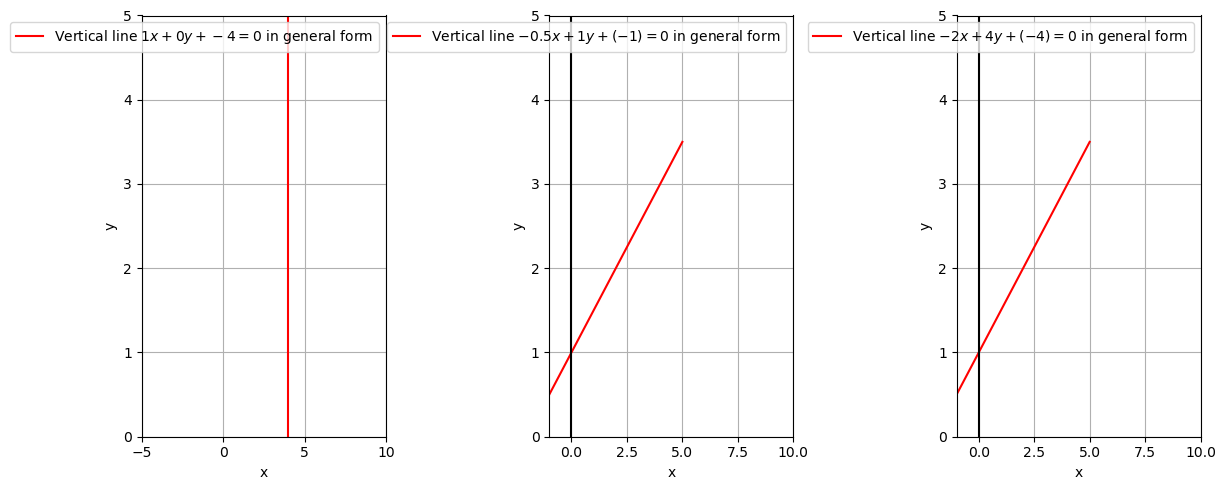

In [3]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
# Plot vertical line using general form
A, B, C = 1, 0, -4 # Ax + 0y + C = 0 
x = -C / A 
y = np.linspace(0, 10, 100)
x_vals = np.full_like(y, x) # repeats x len(y) times
plt.plot(x_vals, y,label=rf"Vertical line ${A}x+{B}y+{C}=0$ in general form",color="red")
plt.xlim(-5, 10)
plt.ylim(0,5)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.subplot(1,3,2)
# Plot line using general form
A,B,C = -0.5,1,-1 # Ax + By + C = 0
x_vals = np.linspace(-5,5,100)
y_vals = (-A/B)*x_vals + (-C/B)
plt.plot(x_vals, y_vals,label=rf"Vertical line ${A}x+{B}y+({C})=0$ in general form",color="red")
plt.xlim(-1, 10)
plt.ylim(0,5)
plt.axvline(0,color="black")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.subplot(1,3,3)
# Plot line using general form
A,B,C = -2,4,-4 # Ax + By + C = 0
x_vals = np.linspace(-5,5,100)
y_vals = (-A/B)*x_vals + (-C/B)
plt.plot(x_vals, y_vals,label=rf"Vertical line ${A}x+{B}y+({C})=0$ in general form",color="red")
plt.xlim(-1, 10)
plt.ylim(0,5)
plt.axvline(0,color="black")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.tight_layout()
plt.show()

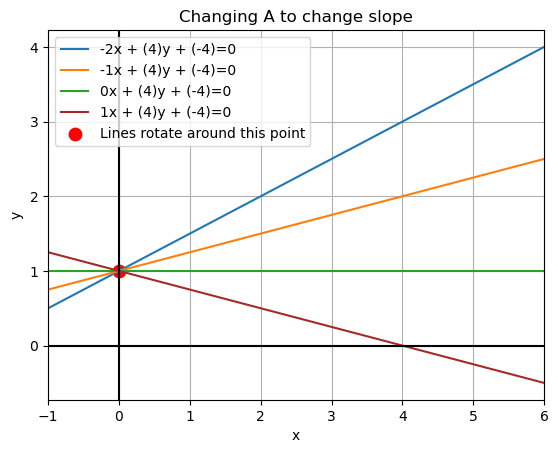

In [4]:
x = np.linspace(-2,6,100)
A,B,C = -2,4,-4
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -1,4,-4 # increased A / slope decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = 0,4,-4 # increased A / slope decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = 1,4,-4 # increased A / slope decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0",color="brown")

plt.scatter(0,-(C/B),color="red",label="Lines rotate around this point",s=80)

plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.title("Changing A to change slope")
plt.xlim(-1,np.max(x))
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

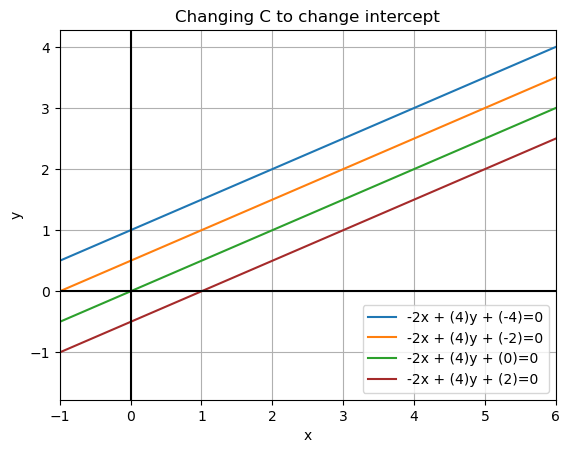

In [5]:
x = np.linspace(-2,6,100)
A,B,C = -2,4,-4
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,4,-2 # increased C / intercept decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,4,0 # increased C / intercept decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,4,2 # increased C / intercept decreases
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0",color="brown")

plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.title("Changing C to change intercept")
plt.xlim(-1,np.max(x))
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

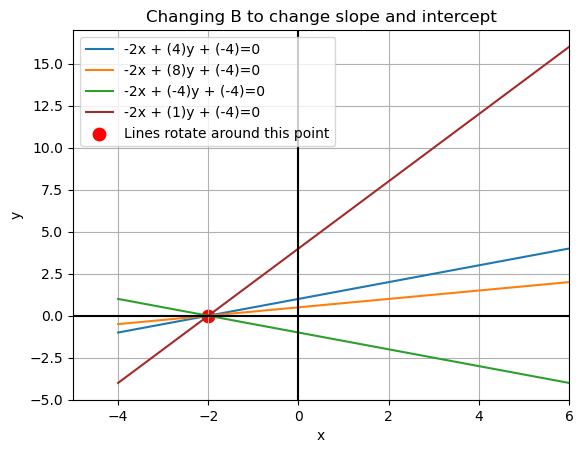

In [6]:
x = np.linspace(-4,6,100)
A,B,C = -2,4,-4
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,8,-4 # increased B 
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,-4,-4 # decreased B
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0")

A,B,C = -2,1,-4 # decreased B
plt.plot(x,-(A/B)*x - C/B,label=f"{A}x + ({B})y + ({C})=0",color="brown")

plt.scatter(A,0,color="red",label="Lines rotate around this point",s=80)
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.title("Changing B to change slope and intercept")
plt.xlim(-5,np.max(x))
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

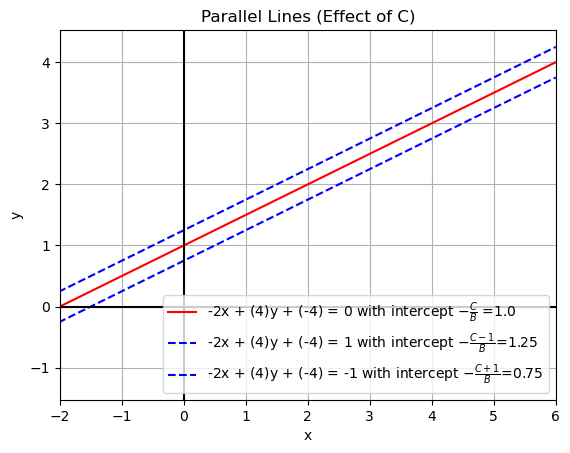

In [7]:
x = np.linspace(-4, 6, 100)

A, B = -2, 4

# original C
C0 = -4
y0 = -(A/B)*x - C0/B
plt.plot(x, y0, label=rf"{A}x + ({B})y + ({C0}) = 0 with intercept $-\frac{{C}}{{B}}$ ={-C0/B}",color="red")

# shifted line (C - 1)
C1 = C0 - 1
y1 = -(A/B)*x - C1/B
plt.plot(x, y1, label=rf"{A}x + ({B})y + ({C0}) = 1 with intercept $-\frac{{C-1}}{{B}}$={-(C0-1)/B}",color="blue",linestyle="--")

# shifted line (C + 1)
C2 = C0 + 1
y2 = -(A/B)*x - C2/B
plt.plot(x, y2, label=rf"{A}x + ({B})y + ({C0}) = -1 with intercept $-\frac{{C+1}}{{B}}$={-(C0+1)/B}",color="blue",linestyle="--")

plt.axvline(0, color="black")
plt.axhline(0, color="black")
plt.title("Parallel Lines (Effect of C)")
plt.xlim(-2, np.max(x))
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid()



plt.show()

### Scaling constants $A,B$ and $C$

<div style="display:flex; gap:20px;">


<div style="
padding:16px;
border-radius:8px;
width:50%;
">

$$
\begin{align*}
k(Ax + By + C) &= 0 \hspace{1 mm} \mid \hspace{1 mm} k \in \mathbb{R}_{>0} \\ \Leftrightarrow
kAx + kBy + kC &= 0 \\ \Leftrightarrow
kBy  &= -kAx - kC \\ \Leftrightarrow
ky  &= -\frac{kA}{B}x - \frac{kC}{B} \\ \Leftrightarrow
y  &= -\frac{A}{B}x - \frac{C}{B} \\ 
\end{align*} 
$$

- Scaling $Ax + By + C$ of $Ax + By + C=0$ with $k \in \mathbb{R}_{>0}$ does not change the line


</div>


<div style="
padding:16px;
border-radius:8px;
width:50%;
">
Case 1: Upper parallel dashed line

$$
\begin{align*}
k(Ax + By + C) &= 1 \hspace{1 mm} \mid \hspace{1 mm} k \in \mathbb{R}_{>0} \\ \Leftrightarrow
Ax + By + C &= \frac{1}{k} \\ \Leftrightarrow
Ax + By + \underbrace{C - \frac{1}{k}}_{\text{new constant}} &= 0 \\ 
\end{align*} 
$$
- new intercept is $-\frac{C - \frac{1}{k}}{B}=-\frac{C}{B} + \frac{1}{kB}$

    - If $k < 1$ then $\frac{1}{k} > 1$ so $\frac{1}{kB}$ is large and positive $\Rightarrow$ intercept increases a lot (line moves up fast ;if $B>0$ otherwise directions reverse)

    - If $k > 1$ then $\frac{1}{k} < 1$ so $\frac{1}{kB}$ is small and positive $\Rightarrow$ intercept increases slightly (line moves up slow ;if $B>0$ otherwise directions reverse)


Case 2: Lower parallel dashed line

$$
\begin{align*}
k(Ax + By + C) &= -1 \hspace{1 mm} \mid \hspace{1 mm} k > 0 \\ \Leftrightarrow
Ax + By + C &= -\frac{1}{k} \\ \Leftrightarrow
Ax + By + \underbrace{C + \frac{1}{k}}_{\text{new constant}} &= 0 \\ 
\end{align*} 
$$

- new intercept is $-\frac{C + \frac{1}{k}}{B}=-\frac{C}{B} - \frac{1}{kB}$

    - If $k < 1$ then $\frac{1}{k} > 1$ so $\frac{1}{kB}$ is large and negative $\Rightarrow$ intercept decreases a lot (line moves down fast ;if $B>0$ otherwise directions reverse)

    - If $k > 1$ then $\frac{1}{k} < 1$ so $\frac{1}{kB}$ is small and negative $\Rightarrow$ intercept decreases slightly (line moves down slow ;if $B>0$ otherwise directions reverse)


</div>
</div>

**Note: For k < 0 then $\frac{1}{k} < 0$ so "upper" line becomes "lower" and "lower" line becomes "upper".**

<p align="center">
<img src="pics/13.jpg" width="500"/>
</p>

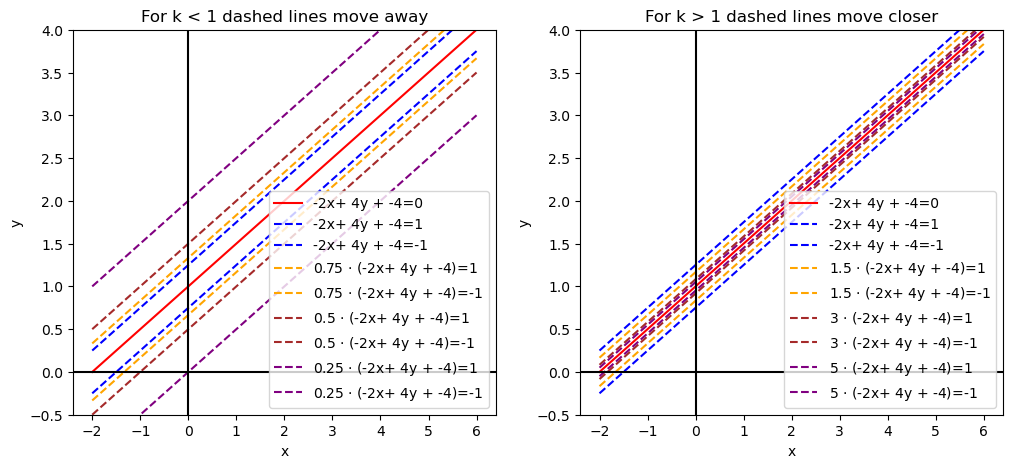

In [8]:
x = np.linspace(-2,6,100)

A,B,C = -2,4,-4
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x,-(A/B)*x-(C/B),color="red",label=f"{A}x+ {B}y + {C}=0")
plt.plot(x,-(A/B)*x-((C-1)/B),color="blue",linestyle="--",label=f"{A}x+ {B}y + {C}=1")
plt.plot(x,-(A/B)*x-((C+1)/B),color="blue",linestyle="--",label=f"{A}x+ {B}y + {C}=-1")

for k,color in zip([0.75,0.5,0.25],["orange", "brown","purple"]):
    plt.plot(x,-(A/B)*x-((C-1/k)/B),linestyle="--",label=rf"{k} $\cdot$ ({A}x+ {B}y + {C})=1",color=color)
    plt.plot(x,-(A/B)*x-((C+1/k)/B),linestyle="--",label=rf"{k} $\cdot$ ({A}x+ {B}y + {C})=-1",color=color)

plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.ylim((-0.5,4))
plt.xlabel("x")
plt.ylabel("y")
plt.title("For k < 1 dashed lines move away")
plt.legend()


plt.subplot(1,2,2)
plt.plot(x,-(A/B)*x-(C/B),color="red",label=f"{A}x+ {B}y + {C}=0")
plt.plot(x,-(A/B)*x-((C-1)/B),color="blue",linestyle="--",label=f"{A}x+ {B}y + {C}=1")
plt.plot(x,-(A/B)*x-((C+1)/B),color="blue",linestyle="--",label=f"{A}x+ {B}y + {C}=-1")

for k,color in zip([1.5,3,5],["orange", "brown","purple"]):
    plt.plot(x,-(A/B)*x-((C-1/k)/B),linestyle="--",label=rf"{k} $\cdot$ ({A}x+ {B}y + {C})=1",color=color)
    plt.plot(x,-(A/B)*x-((C+1/k)/B),linestyle="--",label=rf"{k} $\cdot$ ({A}x+ {B}y + {C})=-1",color=color)

plt.legend()
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.ylim((-0.5,4))
plt.xlabel("x")
plt.ylabel("y")
plt.title("For k > 1 dashed lines move closer")


plt.show()

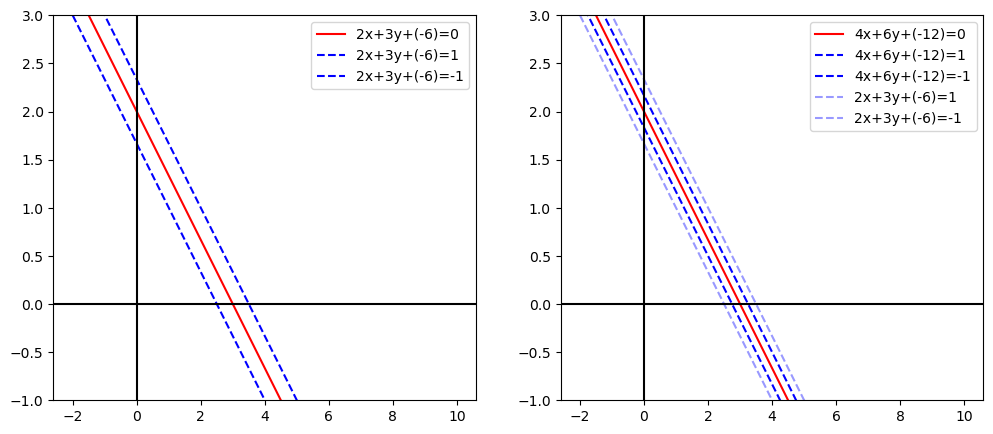

In [9]:
x = np.linspace(-2,10,100)

A,B,C = 2,3,-6

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x,(-A/B)*x - C/B,color="red",label=f"{A}x+{B}y+({C})=0")
plt.plot(x,(-A/B)*x - (C-1)/B,color="blue",label=f"{A}x+{B}y+({C})=1",linestyle="--")
plt.plot(x,(-A/B)*x - (C+1)/B,color="blue",label=f"{A}x+{B}y+({C})=-1",linestyle="--")
plt.ylim((-1,3))
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.legend()


plt.subplot(1,2,2)
k = 2
plt.plot(x,(-A/B)*x - C/B,color="red",label=f"{k*A}x+{k*B}y+({k*C})=0")
plt.plot(x,(-A/B)*x - (C-1/k)/B,color="blue",label=f"{k*A}x+{k*B}y+({k*C})=1",linestyle="--")
plt.plot(x,(-A/B)*x - (C+1/k)/B,color="blue",label=f"{k*A}x+{k*B}y+({k*C})=-1",linestyle="--")
plt.plot(x,(-A/B)*x - (C-1)/B,color="blue",label=f"{A}x+{B}y+({C})=1",linestyle="--",alpha=0.4)
plt.plot(x,(-A/B)*x - (C+1)/B,color="blue",label=f"{A}x+{B}y+({C})=-1",linestyle="--",alpha=0.4)
plt.ylim((-1,3))
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.legend()


plt.show()

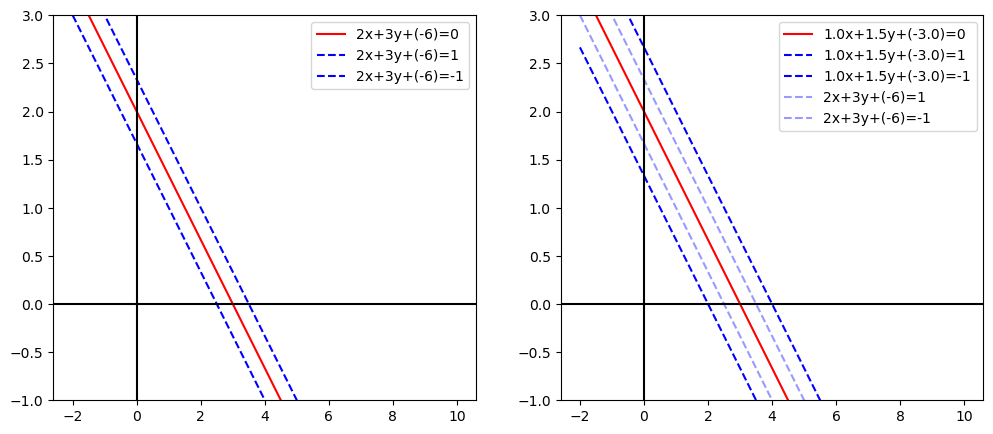

In [10]:
x = np.linspace(-2,10,100)

A,B,C = 2,3,-6

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x,(-A/B)*x - C/B,color="red",label=f"{A}x+{B}y+({C})=0")
plt.plot(x,(-A/B)*x - (C-1)/B,color="blue",label=f"{A}x+{B}y+({C})=1",linestyle="--")
plt.plot(x,(-A/B)*x - (C+1)/B,color="blue",label=f"{A}x+{B}y+({C})=-1",linestyle="--")
plt.ylim((-1,3))
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.legend()


plt.subplot(1,2,2)
k = 0.5
plt.plot(x,(-A/B)*x - C/B,color="red",label=f"{k*A}x+{k*B}y+({k*C})=0")
plt.plot(x,(-A/B)*x - (C-1/k)/B,color="blue",label=f"{k*A}x+{k*B}y+({k*C})=1",linestyle="--")
plt.plot(x,(-A/B)*x - (C+1/k)/B,color="blue",label=f"{k*A}x+{k*B}y+({k*C})=-1",linestyle="--")
plt.plot(x,(-A/B)*x - (C-1)/B,color="blue",label=f"{A}x+{B}y+({C})=1",linestyle="--",alpha=0.4)
plt.plot(x,(-A/B)*x - (C+1)/B,color="blue",label=f"{A}x+{B}y+({C})=-1",linestyle="--",alpha=0.4)
plt.ylim((-1,3))
plt.axvline(0,color="black")
plt.axhline(0,color="black")
plt.legend()


plt.show()

### Distance between a point $(x_0,y_0)$ and a ponit on the line $Ax_0 + By_0 + C = z$

$$
\text{distance} = \frac{\mid Ax_0 + By_0 + (C-z) \mid}{\sqrt{A^2 + B^2}}
$$

<p align="center">
<img src="pics/9.jpg" width="500"/>
</p>

### Distance between two parallel lines $Ax + By + C = z$ and $Ax + By + C = z'$

$$
\text{distance} = \frac{\mid Ax + By + (C-z) - (Ax + By + (C-z'))\mid}{\sqrt{A^2 + B^2}} = \frac{\mid z -  z'\mid}{\sqrt{A^2 + B^2}}
$$


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/10.jpg" width="500"/>
  <img src="pics/11.jpg" width="500"/>
</div>

<a class="anchor" id="idea"></a>
# 1. Intrioduction

## Idea 1

- Use the general equation form to express decision boundariess either as lines, planes or hyperplanes
- Example in 2d: Express $y=mx+b$ as $Ax+By+C=0$


## Idea 2
- Separate classes based on the distance to the closest points.
- Here is an exapmle in 2d


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/17.jpg" width="500"/>
  <img src="pics/margin.jpg" width="500"/>
</div>

- Now we not only require the decision boundary $Ax+By+C=0$ but also the safety margins $Ax+By+C=z$ and $Ax+By+C=-z$. 


## Idea 3
- It is apparent that we want to maximize the with of the safety margins
- For that we need to derive the precise equation of the decision boundary
- Again we see how this works in 2d

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/18.jpg" width="500"/>
  <img src="pics/19.jpg" width="500"/>
</div>


## Idea 4
- In SVM the value for $z$ is 1
- The reason for this is the scaling invariance of the lines
- $w^\top x + b=z$ and $kw^\top x + kb=kz$ $(k \neq 0)$ describe the same decision boundary and the same goes for  $w^\top x + b=z$ and $\frac{w^\top x}{z} +\frac{b}{z}=\frac{z}{z}=1$
- We specifically choose to rescale to 1 because it gives a canonical (standardized) representation
    - The closest points (support vectors) satisfy:
    $$
    w^\top x^{(i)} + b = \begin{cases}
    1 & \text{if } x^{(i)} \text{ is above the decision boundary} \\
    -1 & \text{if } x^{(i)} \text{ is below the decision boundary}
    \end{cases}
    $$
    - This makes the margin width clean:
    $$
    \text{margin width}=\frac{2}{\lVert w \rVert}
    $$
<p align="center">
<img src="pics/20.jpg" width="500"/>
</p>

## Conclusion
<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/21.jpg" width="500"/>
  <img src="pics/22.jpg" width="500"/>
</div>


## How do Support Vectors arise?

Start with any separating solution: $$y^{(i)}(w^\top \cdot  x^{(i)} + b)$$
Now define: $$\gamma = \min_i y^{(i)}(w\top \cdot x^{(i)} + b)$$
This is the smallest functional margin. Now rescale:

$$w' = \frac{w}{\gamma}, \quad b' = \frac{b}{\gamma}$$
Then: $$y^{(i)}(w'^\top \cdot x^{(i)} + b') \geq 1$$

&#128073; and for at least one point: $$y^{(i)}(w'^\top \cdot x^{(i)} + b') = 1$$

and we call that data point $x^{(i)}$ a support vector (SV).

**We consider all separating hyperplanes and minimize $\lvert w \rVert$. If the smallest value $y^{(i)}(w^\top \cdot  x^{(i)} + b)$ is greater than 1, we can rescale $(w,b)$ down to further reduce $\lvert w \rVert$ without changing the decision boundary.Therefore, at the optimum, the smallest value must be exactly 1.The points achieving this minimum are the support vectors.**




<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/14.jpg" width="500"/>
  <img src="pics/15.jpg" width="500"/>
</div>

Before scaling:
Positive: [4 6]
Negative: [-4 -6]
Closest value: 4

After scaling:
Positive: [1.  1.5]
Negative: [-1.  -1.5]
Closest value: 1.0


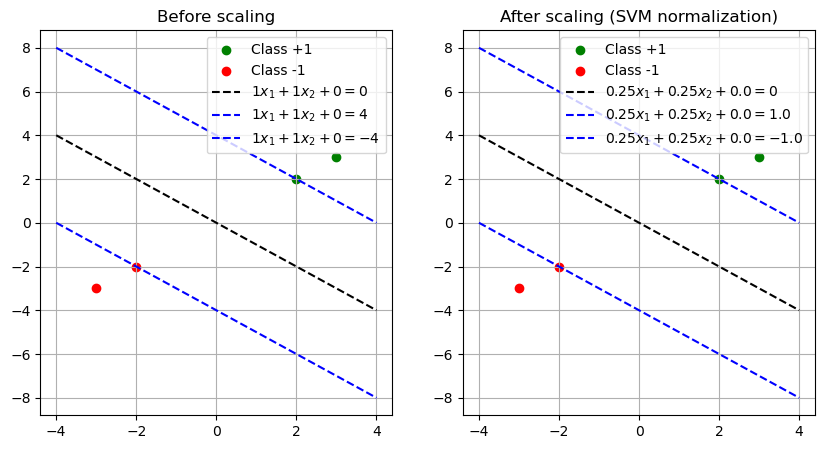

In [11]:
# Data 
X_pos = np.array([[2,2],[3,3]])
X_neg = np.array([[-2,-2],[-3,-3]])

# Step 1: initial separator 
w = np.array([1,1])
b = 0

def f(x, w, b):
    return x @ w + b

# compute values
vals_pos = f(X_pos, w, b)
vals_neg = f(X_neg, w, b)

print("Before scaling:")
print("Positive:", vals_pos)
print("Negative:", vals_neg)

# Step 2: find closest points (support vectors)
closest_val = min(np.min(np.abs(vals_pos)), np.min(np.abs(vals_neg)))
print("Closest value:", closest_val)

# Step 3: rescale 
w_scaled = w / closest_val
b_scaled = b / closest_val

# compute new values
vals_pos_scaled = f(X_pos, w_scaled, b_scaled)
vals_neg_scaled = f(X_neg, w_scaled, b_scaled)

print("\nAfter scaling:")
print("Positive:", vals_pos_scaled)
print("Negative:", vals_neg_scaled)

closest_val_scaled = min(np.min(np.abs(vals_pos_scaled)), np.min(np.abs(vals_neg_scaled)))
print("Closest value:", closest_val_scaled)

# Plot 
x = np.linspace(-4,4,100)

def line(x, w, b, c):
    # w1*x1 + w2*x2 + b = c  → x2 = ...
    return (-w[0]*x - b + c)/w[1]

plt.figure(figsize=(10,5))

# Before scaling
plt.subplot(1,2,1)
plt.scatter(X_pos[:,0], X_pos[:,1], color='green', label='Class +1')
plt.scatter(X_neg[:,0], X_neg[:,1], color='red', label='Class -1')

plt.plot(x, line(x,w,b,0), 'k--', label=rf'${w[0]}x_1 + {w[1]}x_2 + {b} = 0$')
plt.plot(x, line(x,w,b,closest_val), 'b--', label=rf'${w[0]}x_1 + {w[1]}x_2 + {b} = {closest_val}$')
plt.plot(x, line(x,w,b,-closest_val), 'b--', label=rf'${w[0]}x_1 + {w[1]}x_2 + {b} = {-closest_val}$')

plt.title("Before scaling")
plt.legend()
plt.grid()

# After scaling
plt.subplot(1,2,2)
plt.scatter(X_pos[:,0], X_pos[:,1], color='green', label='Class +1')
plt.scatter(X_neg[:,0], X_neg[:,1], color='red', label='Class -1')

plt.plot(x, line(x,w_scaled,b_scaled,0), 'k--', label=rf'${w_scaled[0]}x_1 + {w_scaled[1]}x_2 + {b_scaled} = 0$')
plt.plot(x, line(x,w_scaled,b_scaled,1), 'b--', label=rf'${w_scaled[0]}x_1 + {w_scaled[1]}x_2 + {b_scaled} = {closest_val_scaled}$')
plt.plot(x, line(x,w_scaled,b_scaled,-1), 'b--', label=rf'${w_scaled[0]}x_1 + {w_scaled[1]}x_2 + {b_scaled} = {-closest_val_scaled}$')

plt.title("After scaling (SVM normalization)")
plt.legend()
plt.grid()

plt.show()

<a class="anchor" id="optim"></a>
# 2. Constrained optimization problems

<a class="anchor" id="primal"></a>
## 2.1 Hard margin primal problem

$$
\begin{align*}
\min_{w,b} \quad  &\frac{1}{2}\lVert w \rVert^2 \\
\text{subject to} \quad & y^{(i)}(w^\top x^{(i)} + b) \geq 1 \hspace{1 mm} \text{ for all }i 

\end{align*}
$$




<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Hard margin Primal problem for Quadratic programming
$$
\begin{align*}
\min_x \quad  &\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & Ax \leq b  \\
& A_\text{eq} x = b_\text{eq} \\
&x_l \leq x \leq x_u
\end{align*}
$$



</div>




<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Interior point nonlinear optimization (alternative to Quadratic Programming)

$$
\begin{align*}
\min_x \quad  &f(x)=\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & g_l \leq g(x) \leq g_u  \\
&x_l \leq x \leq x_u
\end{align*}
$$

- $(-\infty \leq Ax \leq b)  \wedge ((b_{eq} \leq A_{eq}x \leq b_{eq})) \\ \Leftrightarrow \begin{bmatrix}-\infty_m \\b_{eq}\end{bmatrix} \leq \begin{bmatrix} A\\A_{eq}\end{bmatrix}x \leq \begin{bmatrix}b \\b_{eq}\end{bmatrix} \Leftrightarrow g_l \leq g(x) \leq g_u$
- $m$ is number of rows of $A$
- we have objective $f(x)$ and constraints $g(x)$
- gradients are $\nabla_x f(x) = Qx+c, \nabla_x g(x)=\begin{bmatrix}A\\A_{eq}\end{bmatrix}$
- Hessian of Lagrangian is $\nabla_x^2 \mathcal{L}(x) = Q$

</div>
</div>

**Terms of Hard margin Primal problem for Quadratic Programming**

- $\min_{w,b} \frac{1}{2}\lVert w \rVert^2 \Leftrightarrow \min_x \frac{1}{2} \begin{bmatrix} w \\ b \end{bmatrix}^T \begin{bmatrix} I_d & 0_d \\ 0_d & 0_d  \end{bmatrix} \begin{bmatrix} w \\ b \end{bmatrix} + 0_{d+1}^T \begin{bmatrix} w \\ b \end{bmatrix}$ with $x=\begin{bmatrix} w \\ b \end{bmatrix}$,  $Q=\begin{bmatrix} I_d & 0_d \\ 0_d & 0_d  \end{bmatrix}$ and $c=0_{d+1}^T$
- $Q = \text{Diag}(y) XX^\top \text{Diag}(y)$
- $x_l=-\infty \cdot \mathcal{1_{d+1}}$ and $x_u=\infty \cdot \mathcal{1_{d+1}}$ (no bounds on $w$ and $b$)
- $A_\text{eq} \in \mathbb{R}^{0 \text{ x } d+1}$ and $b_\text{eq} \in \mathbb{R}^0$ (no equality constraints)
- 
$$
\begin{align*}
y_i(w^Tx_i + b) \geq 1 &\Leftrightarrow y_iw^Tx_i + y_ib \geq 1 \hspace{2 mm} \text{ for all }i \\
&\Leftrightarrow -y_iw^Tx_i - y_ib \leq -1 \\
&\Leftrightarrow (-y_ix_i^T \hspace{0.2cm} -y_i) \begin{bmatrix} w \\ b \end{bmatrix} \leq -\mathcal{1_n} \\
&\Leftrightarrow \begin{bmatrix} -y_1x_1^T & -y_1 \\  \vdots &  \vdots \\ -y_nx_n^T & -y_n \end{bmatrix}\begin{bmatrix} w \\ b \end{bmatrix} \leq -\mathcal{1_n} \\
&\Leftrightarrow -\text{Diag}(y) [X \hspace{0.2cm} \mathcal{1_n}] \begin{bmatrix} w \\ b \end{bmatrix} \leq -\mathcal{1_n} 
\end{align*}
$$

- $A=-\text{Diag}(y) [X \hspace{0.2cm} \mathcal{1_n}]$
- $b=-\mathcal{1_n}$


Solve this ...
- by plugging it directly into some optimization software 
- or apply method of **Lagrange multiplier** to derive the dual problem and
then solve the dual problem which is sometimes easier then the primal

```python

# 1. scipy.optimize.minimize  (solve optimization problems)

from scipy.optimize import minimize

minimize(fun, x0, args=(), method=None, jac=None, bounds=None, constraints=())

# fun: function to minimize
# x0: initial guess for variables
# args: extra arguments passed to fun
# method: optimization algorithm (e.g. 'SLSQP' for constrained problems)
# jac: gradient (optional but faster)
# bounds: variable bounds
# constraints: equality / inequality constraints

# Example structure for SVM dual:

def dual_objective(alpha, X, y):
    # 1/2 * alpha^T Q alpha - sum(alpha)
    Q = (y[:, None] * X) @ (y[:, None] * X).T
    return 0.5 * alpha @ Q @ alpha - np.sum(alpha)

# initial guess
alpha0 = np.zeros(n_samples)

# call optimizer
result = minimize(
    fun=dual_objective,
    x0=alpha0,
    args=(X, y),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

alpha_opt = result.x  # optimal alphas


# 2. scipy.optimize.Bounds  (box constraints)

from scipy.optimize import Bounds

# Bounds(lb, ub)

# lb: lower bounds (array or scalar)
# ub: upper bounds (array or scalar)

# Hard-margin SVM:
bounds = Bounds(0, np.inf) # alpha_i >= 0

# Soft-margin SVM:
C = 1.0
bounds = Bounds(0, C) # 0 <= alpha_i <= C



# 3. scipy.optimize.LinearConstraint  (equality constraint)

from scipy.optimize import LinearConstraint

# LinearConstraint(A, lb, ub)

# A: matrix
# lb, ub: lower/upper bounds

# For SVM constraint: sum(alpha_i y_i) = 0

linear_constraint = LinearConstraint(
    A=y,     # shape (n_samples,)
    lb=0,
    ub=0
)



# 4. sklearn.datasets.make_blobs  (generate toy data)

from sklearn.datasets import make_blobs

# make_blobs(n_samples, n_features, centers, cluster_std, random_state)

X, y = make_blobs(
    n_samples=100, # number of data points
    n_features=2, # dimensionality
    centers=2, # number of classes
    cluster_std=1.5, # spread of clusters
    random_state=42
)

# Convert labels {0,1} -> {-1,+1} for SVM
y = np.where(y == 0, -1, 1)



# 5. After optimization (recover model parameters)

# Compute w
w = np.sum(alpha_opt[:, None] * y[:, None] * X, axis=0)

# Identify support vectors
support_vectors = X[alpha_opt > 1e-5]

# Compute b using support vectors
b_vals = y[alpha_opt > 1e-5] - support_vectors @ w
b = np.mean(b_vals)

# Prediction function
def predict(X_new):
    return np.sign(X_new @ w + b)



# 6. Summary (mental map)

# minimize()  -> solves dual optimization
# Bounds  -> enforce box constraints
# LinearConstraint -> enforce linear equality constraints
# make_blobs  -> generate synthetic classification data

# Output:
# alpha -> identifies support vectors
# w, b  -> define decision boundary

```

**Recall Quadratic Programming setup**
$$
\begin{align*}
\min_x \quad  &\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & Ax \leq b  \\
& A_\text{eq} x = b_\text{eq} \\
&x_l \leq x \leq x_u
\end{align*}
$$

In [12]:
# implement quadprog using scipy.optimize.minimize
def quadprog(Q, c, A=None, b=None, Aeq=None, beq=None, lb=None, ub=None, x0=None):
    """
    Generic quadratic programming (QP) solver wrapper around scipy.optimize.minimize.
    It solves problems of the form:
        min  0.5 * x.T @ Q @ x + c.T @ x
        s.t. A @ x <= b
            Aeq @ x == beq
            lb <= x <= ub
    init x with x0

    Input:
        - Q: Hessian matrix of the quadratic term
        - c: Linear term
        - A, b: Inequality constraints Ax <= b
        - Aeq, beq: Equality constraints Aeqx = beq
        - lb, ub: Box constraints lb <= x0 <= ub
        - x0: Initial point

    Output: object of type <class 'scipy.optimize.OptimizeResult'> containing optimal solution
    """

    if A is None: A = np.zeros((0, len(c))) # A = array([], shape=(0, np.len(c)), dtype=float64) with lenght 0
    if b is None: b = np.zeros(0) # b = array([], dtype=float64) with lenght 0
    if Aeq is None: Aeq = np.zeros((0, len(c))) # Aeq = array([], shape=(0, np.len(c)), dtype=float64) with lenght 0
    if beq is None: beq = np.zeros(0) # beq = array([], dtype=float64) with lenght 0
    if lb is None: lb = -np.inf * np.ones(len(c)) # lower bound for x0
    if ub is None: ub = np.inf * np.ones(len(c)) # upper bound for x0
    if x0 is None: x0 = np.zeros(c.shape[0]) # x0 = array([], dtype=float64) with lenght 0 (starting point for the optimizer)
    # c.shape[0] == len(c) since c is one dimensional

    fun = lambda x: 0.5 * x.T @ Q @ x + c.T @ x # f(x) objective function

    bounds = Bounds(lb, ub) # scipy.optimize.Bounds(lb, ub)
    constraints = LinearConstraint( # scipy.optimize.LinearConstraint(...)
        np.vstack([A, Aeq]), # stacks vertically to array([[A], [Aeq]]) = g(x)
        np.concatenate([-np.inf * np.ones(A.shape[0]), beq]), # like vstack it stacks vertically to array([[-np.inf * np.ones(A.shape[0])], [beq]]) = g_l
        np.concatenate([b, beq])) # array([[b], [beq]]) = g_u
    
    return minimize(fun, x0, bounds=bounds, constraints=constraints) # scipy.optimize.minimize(...)

**Recall the SVM primal as Quadratic Program:**
$$
Q=\begin{bmatrix} I_d & 0_d \\ 0_d & 0_d  \end{bmatrix}, \hspace{0.3cm} c=0_{d+1}^T \text{ for data }x_i \in \mathbb{R}^d \hspace{0.2cm}i=1,..,n \\
A = -\text{Diag}(y) [X \hspace{0.2cm} \mathcal{1_n}], \hspace{0.3cm} b=-\mathcal{1_n}, \hspace{0.3cm}   x  = \begin{bmatrix}w \\b\end{bmatrix} \\
A_{eq} \in \mathbb{R}^{0 \text{ x } d+1}, \hspace{0.3cm} b_{eq} \in \mathbb{R}^0 \\
x_l=-\infty \cdot \mathcal{1_{d+1}}, \hspace{0.3cm} x_u=\infty \cdot \mathcal{1_{d+1}}

$$




In [13]:
def linear_separable_svm_primal(X, y):
    """
    Compute weights vector and b for linear separable SVM
    Input:
        - X: data as matrix of shappe (n,d)
        - y: vector of +1 and -1 of shape (n,)
    Output: 
        - w: vector of weights of shape (d,)
        - b: offset as float
    """
    n, d = X.shape

    # Set up the quadratic program
    Q = np.zeros((d + 1, d + 1))
    Q[:d, :d] = np.identity(d)

    c = np.zeros(d + 1) # array([0., 0., ..., 0.]) with d+1 zeros

    A = -np.diag(y) @ np.hstack([X, np.ones((n, 1))]) # -diag(y) @ [X  1_n]
    b = -np.ones(n) # array([-1., -1., -1., ...,-1.]) with n times

    # Solve the quadratic program
    result = quadprog(Q, c, A=A, b=b) # uses default values for rest so Aeq = zeros(0, c.shape[0]), beq = np.zeros(0), 
                                      #                                 lb = -np.inf * np.ones(c.shape[0]), ub = np.inf * np.ones(c.shape[0]), 
                                      #                                 x0 = zeros(c.shape[0])
    x = result.x # optimal solution for Primal: result.x = [w_1, ..., w_d, b]

    # Extract weights and bias
    w = x[:d] # extract weights from 0 to d-1
    b = x[d] # extract b at end of x

    return w, b


def predict(x, w, b):
    """
    Predict class of new features x given w and b
    Input:
        - x: feature matrix of shape (d,n)
        - w: weights vector of shape (d,)
        - b: offset as float
    Output:
        - y_predicted: Predictions as boolean array (1 = Class +1, 0 = Class -1)

    """
    y_predicted = (x @ w + b > 0.0).astype(int)
    return y_predicted


def accuracy(x, y, w, b):
    """
    Get rate of correctly predicted classes
    Input:
        - x: feature matrix of shape (d,n)
        - y: vector of +1 and -1 of shape (n,)
        - w: weights vector of shape (d,)
        - b: offset as float
        
    Output: Rate of correcte predicted classes as float (between 0 and 1) 

    """
    return (y * (x @ w + b) > 0.0).mean()

For a 2-dimensional hyperplane, we can plot the decision boundary as a line:
$$
w^\top x + b = 0
\iff w_1 x_1 + w_2 x_2 + b = 0
\iff x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}  \\

w^\top x + b = 1 
\iff w_1 x_1 + w_2 x_2 + b = 1
\iff x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2} + \frac{1}{w_2} \\

w^\top x + b = -1 
\iff w_1 x_1 + w_2 x_2 + b = -1
\iff x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2} - \frac{1}{w_2} 
$$

In [33]:
n = 100 # number of observations
X,y = make_blobs(n_samples=n,n_features=2,centers=2,cluster_std=1.0,random_state=1901) 
print("Shape of X",X.shape) # 100 2 dimensional data points
print("class labels:",np.unique(y))
y = y*2.0-1 # change class labels from 1 and 0 to +1 and -1
print("New class labels:",np.unique(y))


fig1 = px.scatter(
    x=X[:, 0],y=X[:, 1],
    color=np.where(y == 1, "Class +1", "Class -1"),
    title="Linearly Separable SVM primal",
    color_discrete_map={"Class -1": "red","Class +1": "green"},labels={"x": "x1","y": "x2","color": "Class"})

fig1.update_xaxes(range=[-4, 5])
fig1.update_yaxes(range=[-6.5, 2])

w,b = linear_separable_svm_primal(X, y)
print(f'Weights: {w}')
print(f'Bias: {b:.8f}')
print(f"Accuracy = {accuracy(X, y, w, b)}")
new_data = np.random.uniform(-3,4,(10,2)) # 10 new data points to classifiy
predictions = predict(new_data, w, b)
predictions = np.where(predictions == 1, 1, -1)

# Class +1
mask_pos = predictions == 1
fig1.add_scatter(
    x=new_data[mask_pos, 0],
    y=new_data[mask_pos, 1],
    mode="markers",
    name="New +1",
    marker=dict(symbol="x", color="green", size=12)
)

# Class -1
mask_neg = predictions == -1
fig1.add_scatter(
    x=new_data[mask_neg, 0],
    y=new_data[mask_neg, 1],
    mode="markers",
    name="New -1",
    marker=dict(symbol="x", color="red", size=12)
)

# Create x values
x_line = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100)

# Decision boundary
y_boundary = (-w[0]*x_line - b) / w[1]

fig1.add_scatter(
    x=x_line,
    y=y_boundary,
    mode="lines",
    name="Decision boundary",
    line=dict(color="black", dash="dash")
)

# Margin lines (SVM gutters)
y_margin_pos = (-w[0]*x_line - b - 1) / w[1]
y_margin_neg = (-w[0]*x_line - b + 1) / w[1]

fig1.add_scatter(
    x=x_line,
    y=y_margin_pos,
    mode="lines",
    name="+1 margin",
    line=dict(color="blue", dash="dot")
)

fig1.add_scatter(
    x=x_line,
    y=y_margin_neg,
    mode="lines",
    name="-1 margin",
    line=dict(color="blue", dash="dot")
)

# Compute margins
margins = y * (X @ w + b)

tol = 1e-5
support_mask = np.abs(margins - 1) < tol

support_vectors = X[support_mask]

fig1.add_scatter(
    x=support_vectors[:, 0],y=support_vectors[:, 1],
    mode="markers",name="Support Vectors",
    marker=dict(color="yellow",size=12,line=dict(color="black", width=2)))

fig1.show()


w,b = linear_separable_svm_primal(support_vectors, y[support_mask])
print(f'Same Weights when only considering Support vectors: {w}')
print(f'Same Bias when only considering Support vectors: {b:.8f}')

fig2 = px.scatter(
    x=support_vectors[:, 0],y=support_vectors[:, 1],
    color=np.where(y[support_mask] == 1, "Class +1", "Class -1"),
    title="Linearly Separable SVM primal only Support vectors",
    color_discrete_map={"Class -1": "red","Class +1": "green"},labels={"x": "x1","y": "x2","color": "Class"})

fig2.update_xaxes(range=[-4, 5])
fig2.update_yaxes(range=[-6.5, 2])

# Decision boundary
y_boundary = (-w[0]*x_line - b) / w[1]

fig2.add_scatter(
    x=x_line,
    y=y_boundary,
    mode="lines",
    name="Decision boundary",
    line=dict(color="black", dash="dash")
)

# Margin lines (SVM gutters)
y_margin_pos = (-w[0]*x_line - b - 1) / w[1]
y_margin_neg = (-w[0]*x_line - b + 1) / w[1]

fig2.add_scatter(
    x=x_line,
    y=y_margin_pos,
    mode="lines",
    name="+1 margin",
    line=dict(color="blue", dash="dot")
)

fig2.add_scatter(
    x=x_line,
    y=y_margin_neg,
    mode="lines",
    name="-1 margin",
    line=dict(color="blue", dash="dot")
)

fig2.show()


Shape of X (100, 2)
class labels: [0 1]
New class labels: [-1.  1.]
Weights: [ 1.46751405 -1.86135165]
Bias: -4.37307955
Accuracy = 1.0


Same Weights when only considering Support vectors: [ 1.46751404 -1.86135166]
Same Bias when only considering Support vectors: -4.37307956


In [15]:
np.random.seed(1947)

# Class imbalance
n_pos =60 
n_neg = 10 

# Class -1 
X_neg = np.random.multivariate_normal([-4, 3], [[2, 0], [0, 2]], n_neg)

# Class +1 
X_pos = np.random.multivariate_normal([2, -3], [[2, 0], [0, 2]], n_pos)

# Combine
X = np.vstack((X_neg, X_pos))
y = np.array([-1.0]*n_neg + [1.0]*n_pos)

# readable labels
labels = np.where(y == 1, "Class +1", "Class -1")

# Plot
fig = px.scatter(
    x=X[:, 0],y=X[:, 1],
    color=labels,title="Linear separable SVM primal with imbalanced classes",
    color_discrete_map={"Class -1": "red","Class +1": "green"},labels={"x": "x1","y": "x2","color": "Class"})


w,b = linear_separable_svm_primal(X,y)
print(f'Weights: {w}')
print(f'Bias: {b:.8f}')

# Create x values
x_line = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100)

# Decision boundary
y_boundary = (-w[0]*x_line - b) / w[1]

fig.add_scatter(
    x=x_line,y=y_boundary,
    mode="lines",name="Decision boundary",
    line=dict(color="black", dash="dash"))

# Margin lines (SVM gutters)
y_margin_pos = (-w[0]*x_line - b - 1) / w[1]
y_margin_neg = (-w[0]*x_line - b + 1) / w[1]

fig.add_scatter(
    x=x_line,
    y=y_margin_pos,
    mode="lines",
    name="+1 margin",
    line=dict(color="blue", dash="dot")
)

fig.add_scatter(
    x=x_line,
    y=y_margin_neg,
    mode="lines",
    name="-1 margin",
    line=dict(color="blue", dash="dot")
)

# Compute margins
margins = y * (X @ w + b)

tol = 1e-5
support_mask = np.abs(margins - 1) < tol

support_vectors = X[support_mask]

fig.add_scatter(
    x=support_vectors[:, 0],y=support_vectors[:, 1],
    mode="markers",name="Support Vectors",
    marker=dict(color="yellow",size=12,line=dict(color="black", width=2)))

fig.show()

Weights: [ 0.36700566 -0.40084267]
Bias: 0.69255551


For a 3-dimensional hyperplane, we can plot the decision boundary as a plane:

$$
w^\top x + b = 0
\iff w_1 x_1 + w_2 x_2 + w_3 x_3 + b = 0
\iff x_3 = -\frac{w_1}{w_3} x_1 - \frac{w_2}{w_3} x_2 - \frac{b}{w_3}
$$

$$
w^\top x + b = 1
\iff w_1 x_1 + w_2 x_2 + w_3 x_3 + b = 1
\iff x_3 = -\frac{w_1}{w_3} x_1 - \frac{w_2}{w_3} x_2 - \frac{b}{w_3} + \frac{1}{w_3}
$$

$$
w^\top x + b = -1
\iff w_1 x_1 + w_2 x_2 + w_3 x_3 + b = -1
\iff x_3 = -\frac{w_1}{w_3} x_1 - \frac{w_2}{w_3} x_2 - \frac{b}{w_3} - \frac{1}{w_3}
$$

In [16]:
np.random.seed(2014)

n = 100

cov = [[2, 0, 0],
       [0, 3, 0],
       [0, 0, 2]]

# Class -1 
X_neg = np.random.multivariate_normal([6, 3, 5], cov, n//2)

# Class +1 
X_pos = np.random.multivariate_normal([-1, -3, 3], cov, n//2)

# Combine
X = np.vstack((X_neg, X_pos))
y = np.array([-1.0]*(n//2) + [1.0]*(n//2))

# Create class labels
class_labels = np.where(y == 1, "Class +1", "Class -1")

# Plot
fig = px.scatter_3d(
    x=X[:, 0],y=X[:, 1],z=X[:, 2],
    color=class_labels, title="3D Linearly Separable SVM primal",
    color_discrete_map={"Class -1": "red","Class +1": "green"},
    labels={"x": "x1","y": "x2","z": "x3","color": "Class"})


w,b = linear_separable_svm_primal(X,y)

print(f'Weights: {w}')
print(f'Bias: {b:.8f}')


# Create grid
x_range = np.linspace(X[:,0].min(), X[:,0].max(), 30)
y_range = np.linspace(X[:,1].min(), X[:,1].max(), 30)
x_grid, y_grid = np.meshgrid(x_range, y_range)

# Decision boundary: w·x + b = 0
z0 = (-w[0]*x_grid - w[1]*y_grid - b) / w[2]

# Margin planes
z_pos = (-w[0]*x_grid - w[1]*y_grid - b - 1) / w[2] # +1
z_neg = (-w[0]*x_grid - w[1]*y_grid - b + 1) / w[2] # -1

# Add surfaces
fig.add_trace(go.Surface(
    x=x_grid, y=y_grid, z=z0,
    opacity=0.5,
    showscale=False,
    name="Decision boundary"
))

fig.add_trace(go.Surface(
    x=x_grid, y=y_grid, z=z_pos,
    opacity=0.3,
    showscale=False,
    colorscale=[[0, 'blue'], [1, 'blue']],
    name="+1 margin"
))

fig.add_trace(go.Surface(
    x=x_grid, y=y_grid, z=z_neg,
    opacity=0.3,
    showscale=False,
    colorscale=[[0, 'blue'], [1, 'blue']],
    name="-1 margin"
))


margins = y * (X @ w + b)

tol = 1e-5
support_mask = np.abs(margins - 1) < tol
support_vectors = X[support_mask]

fig.add_scatter3d(
    x=support_vectors[:, 0],
    y=support_vectors[:, 1],
    z=support_vectors[:, 2],
    mode="markers",
    name="Support Vectors",
    marker=dict(size=6,color="yellow",line=dict(color="black", width=2)))

fig.show()

Weights: [-0.42067144 -0.16885521 -0.34134212]
Bias: 2.54975617


### Apply Lagrange multiplier

$$
\begin{align*}
\max_\alpha \min_{w,b}\mathcal{L}(w,b,\alpha)
&=\frac{1}{2} \lVert w \rVert^2 - \sum_{i=1}^n \alpha_i (y^{(i)}(w^\top x^{(i)} + b)-1) \hspace{1 mm} \mid \hspace{1 mm} \alpha_i \geq 0 \hspace{1mm} \forall i \in \{1,\ldots,n\}  \\

&=\frac{1}{2} w^\top w - \sum_{i=1}^n \alpha_i y^{(i)} w^\top x^{(i)} + \alpha_i y^{(i)}b - \alpha_i   \\

&=\frac{1}{2} w^\top w - w^\top\sum_{i=1}^n \alpha_i y^{(i)}  x^{(i)} - b\sum_{i=1}^n \alpha_i y^{(i)} + \sum_{i=1}^n \alpha_i   \\

&\frac{\partial}{\partial w}\mathcal{L}(w,b,\alpha) = w- \sum_{i=1}^n \alpha_i y^{(i)} x^{(i)} = 0 \Leftrightarrow \color{yellow}w = \sum_{i=1}^n \alpha_i y^{(i)} x^{(i)}\color{white} \\

&\frac{\partial}{\partial b}\mathcal{L}(w,b,\alpha) = -\sum_{i=1}^n \alpha_i y^{(i)}=0 \Leftrightarrow \color{green}\sum_{i=1}^n \alpha_i y^{(i)}=0\color{white} \\

&=\frac{1}{2} \color{yellow}w\color{white}^\top \color{yellow}w\color{white} - \color{yellow}w\color{white}^\top\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)} - b\color{green}\sum_{i=1}^n \alpha_i y^{(i)}\color{white} + \sum_{i=1}^n \alpha_i \\

&=\frac{1}{2} (\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)})^\top \sum_{j=1}^n \alpha_j y^{(j)} x^{(j)} - (\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)})^\top \sum_{j=1}^n \alpha_j y^{(j)} x^{(j)} + \sum_{i=1}^n \alpha_i \\


&=\sum_{i=1}^n \alpha_i - \frac{1}{2} (\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)})^\top \sum_{i=1}^n \alpha_i y^{(i)} x^{(i)} \\

&=\sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i,j=1}^n \alpha_i \alpha_j  y^{(i)} y^{(j)} \langle x^{(i)}, x^{(j)}\rangle \\


\end{align*}
$$

<a class="anchor" id="dual"></a>
## 2.2 Hard margin dual problem

- Given training data $(x^{(1)},y^{(1)}),\ldots,(x^{(n)},y^{(n)})$ with $^{(i)} \in \mathbb{R}^p$ and $y^{(i)} \in \{+1,-1\}$ for $i=1,...n,$
- Find $\alpha$ that solves dual problem

$$
\begin{align*}
\max_{\alpha} \quad  &\sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i,j=1}^n \alpha_i \alpha_j  y^{(i)} y^{(j)} \langle x^{(i)} x^{(j)}\rangle \\ \Leftrightarrow \min_{\alpha} \quad  &\frac{1}{2} \sum_{i,j=1}^n \alpha_i \alpha_j  y^{(i)} y^{(j)} \langle x^{(i)} x^{(j)}\rangle - \sum_{i=1}^n \alpha_i\\
\text{subject to} \quad & \sum_{i=1}^n \alpha_i y^{(i)} = 0 \\
&\alpha_i \geq 0 \hspace{1 mm} \text{ for all }i
\end{align*}
$$


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

##### Hard margin Dual problem in matrix notation
$$
\begin{align*}
\min_{\alpha} \quad  &\frac{1}{2} \alpha^\top Q \alpha - 1_n^\top \alpha \\
\text{subject to} \quad & y^\top \alpha = 0 \\
&\alpha \geq 0 
\end{align*}
$$

$Q = \text{Diag}(y) XX^\top \text{Diag}(y)$



</div>




<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Dual problem for Quadratic programming

$$
\begin{align*}
\min_x \quad  &\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & Ax \leq b  \\
& A_\text{eq} x = b_\text{eq} \\
&x_l \leq x \leq x_u
\end{align*}
$$

- $Q = \text{Diag}(y) XX^\top \text{Diag}(y)$
- $x=\alpha$
- $c=-1_n$
- $A = b = []$ (no inequality constraints)
- $x_l=0$ and $x_u=\infty$ (lower bound on $\alpha$)
- $A_\text{eq}=y^\top$
- $b_\text{eq}=0$



</div>
</div>

#### Use $\alpha$ for classification rule since $w=\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)}$:

$$
\begin{align*}
\text{sgn}(w^\top x + b)
&=\text{sgn}((\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)})^\top x + b)  \\
&= \text{sgn}(\sum_{i=1}^n \alpha_i y^{(i)} \langle x^{(i)},x \rangle + b)=\begin{cases} +1 &\text{ if } \sum_{i=1}^n \alpha_i y^{(i)} \langle x^{(i)},x \rangle + b \geq 0 \\ -1 &\text{ otherwise} \end{cases} \\

\end{align*}
$$

#### Support vectors (separable case)

From $$\alpha_i(y^{(i)}(w^\top x^\top + b)-1)=0 \hspace{2 mm} \text{ for all }i=1,\ldots,n$$ we get two possible cases:

**Case 1: $\alpha_i =0$**

Then 
$$
y^{(i)}(w^\top x^\top + b) \geq 1
$$

&#128073; Point $x^{(i)}$ is irrelevant $\rightarrow$ $x^{(i)}$ is not a support vector

**Case 2: $\alpha_i > 0$**

Then 
$$
y^{(i)}(w^\top x^\top + b) = 1
$$

&#128073; Point $x^{(i)}$ lies on the margin $\rightarrow$ $x^{(i)}$ is a support vector. Set of indices of all support vectors is called $\mathcal{S}$


#### Compute $w$ and $b$ given $\alpha$

$$
w = \sum_{i=1}^n \alpha_i y^{(i)}x^{(i)} = \sum_{i \in \mathcal{S}} \alpha_i y^{(i)}x^{(i)}
$$
&#128073; Only Support vectors contribute to $w$

Now compute $b$ and also only consider support vectors
$$
\begin{align*}
\alpha_i(y_i(w^Tx_i + b)-1)=0 
&\Leftrightarrow \alpha_i y^{(i)} w^\top x^{(i)} + \alpha_i y^{(i)}b - \alpha_i=0 \\ 
&\Leftrightarrow \alpha_i y^{(i)}b = \alpha_i - \alpha_i y^{(i)} w^\top x^{(i)} \\
&\Leftrightarrow  y^{(i)}b = 1 - y^{(i)} w^\top x^{(i)} \\ 
&\Leftrightarrow b^{(i)} = \frac{1}{y^{(i)}} - w^\top x^{(i)} \\
&\Leftrightarrow b^{(i)} = y^{(i)} - w^\top x^{(i)} \text{ since }y^{(i)} \in \{+1,-1\} \\
&\text{All } b^{(i)} \text{ are approximately the same so define } b \text{ as their average} \\
\Rightarrow b &= \frac{1}{|\mathcal{S}|} \sum_{i \in \mathcal{S}} b^{(i)} = \frac{1}{|\mathcal{S}|} \sum_{i \in \mathcal{S}} y^{(i)} - w^\top x^{(i)}

\end{align*}
$$



Geometric interpretation
- We are placing a maximally wide “street” between two classes
- The street expands until it hits points on both sides
- Those points become the walls of the street

&#128073; Those walls = support vectors

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Hard margin Primal problem for Quadratic programming
$$
\begin{align*}
\min_x \quad  &\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & Ax \leq b  \\
& A_\text{eq} x = b_\text{eq} \\
&x_l \leq x \leq x_u
\end{align*}
$$



</div>




<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Interior point nonlinear optimization (alternative to Quadratic Programming)

$$
\begin{align*}
\min_x \quad  &f(x)=\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & g_l \leq g(x) \leq g_u  \\
&x_l \leq x \leq x_u
\end{align*}
$$

- $(-\infty \leq Ax \leq b)  \wedge ((b_{eq} \leq A_{eq}x \leq b_{eq})) \\ \Leftrightarrow \begin{bmatrix}-\infty_m \\b_{eq}\end{bmatrix} \leq \begin{bmatrix} A\\A_{eq}\end{bmatrix}x \leq \begin{bmatrix}b \\b_{eq}\end{bmatrix} \Leftrightarrow g_l \leq g(x) \leq g_u$
- $m$ is number of rows of $A$
- we have objective $f(x)$ and constraints $g(x)$
- gradients are $\nabla_x f(x) = Qx+c, \nabla_x g(x)=\begin{bmatrix}A\\A_{eq}\end{bmatrix}$
- Hessian of Lagrangian is $\nabla_x^2 \mathcal{L}(x) = Q$

</div>
</div>

**Recall the SVM dual as Quadratic Program:**

$$
Q=\text{diag}(y)XX^T\text{diag}(y), \hspace{0.3cm} c = -\mathcal{1}_n \text{ for data }x_i \in \mathbb{R}^d \hspace{0.2cm}i=1,..,n \\
A = b = [], \hspace{0.3cm} x = \alpha \\
A_{eq} = y^T \text{ and }b_{eq}=0 \\
x_l = 0 \text{ and } x_u = \infty
$$

In [17]:
# use quadprog for the implementation
def linear_separable_svm_dual(x, y, threshold=1e-10):
    """
    Compute weights vector and b for linear separable SVM
    Input:
        - X: data as matrix of shappe (n,d)
        - y: vector of +1 and -1 of shape (n,)
        - treshold: float with default
    Output: 
        - w: vector of weights of shape (d,)
        - b: offset as float
        - alpha: alphas of support vectors
    """
    n =  y.shape[0]
    Q =  np.diag(y) @ x @ x.T @ np.diag(y) # Q = y * (x @ x.T) * y.T
    c = -np.ones(n) # c = -1_n

    result = quadprog(Q, c, 
                      Aeq = y.reshape(1, n), # Aeq = y.T
                      beq = np.zeros(1), # beq = 0
                      lb  = np.zeros(n)) # lb = 0
    # use default values: ub = np.inf * np.ones(np.len(c)), A=np.zeros((0, len(c))), b = np.zeros(0), ub = np.inf * np.ones(len(c))
    # x0 = zeros(c.shape[0])

    alpha = result.x # optimal solution for Dual: res.x = [a_1, ..., a_n] so the alphas

    support_vectors = (alpha > threshold) # boolean array meaning x_i lies on the margin
    
    n_support_vectors = support_vectors.sum() # sum up TRUE to get number of support vectors

    alpha = alpha * (support_vectors) # only consider alphas > treshold (so alphas of support vectors => S (set of indices of all support vectors))

    w = (alpha * y) @ x 
    b = ((y - x @ w) * support_vectors).sum() / n_support_vectors # multiply (y - x @ w) with support_vectors to only consider set S 

    return w, b, alpha

In [18]:
np.random.seed(2048)
n = 50 # total number of datapoints
X = np.random.randn(n, 2)
y = np.ones(n).astype(float)
X[:n//2,:] +=  5.0 # separate the classes
y[:n//2]   *= -1  # label the first half -1
w, b, alpha = linear_separable_svm_dual(X, y)
print(f"accuracy = {accuracy(X, y, w, b)}")
print("alpha =\n",alpha)
print(f"w = {w}")
print(f"b = {b}")

fig = px.scatter(
    x=X[:, 0],y=X[:, 1],
    color=np.where(y == 1, "Class +1", "Class -1"),
    title="Linearly Separable SVM dual",
    color_discrete_map={"Class -1": "red","Class +1": "green"},labels={"x": "x1","y": "x2","color": "Class"})

# Create x values
x_line = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100)

# Decision boundary
y_boundary = (-w[0]*x_line - b) / w[1]

fig.add_scatter(
    x=x_line,
    y=y_boundary,
    mode="lines",
    name="Decision boundary",
    line=dict(color="black", dash="dash")
)

# Margin lines (SVM gutters)
y_margin_pos = (-w[0]*x_line - b - 1) / w[1]
y_margin_neg = (-w[0]*x_line - b + 1) / w[1]

fig.add_scatter(
    x=x_line,
    y=y_margin_pos,
    mode="lines",
    name="+1 margin",
    line=dict(color="blue", dash="dot")
)

fig.add_scatter(
    x=x_line,
    y=y_margin_neg,
    mode="lines",
    name="-1 margin",
    line=dict(color="blue", dash="dot")
)

support_vectors = X[alpha > 0]

fig.add_scatter(
    x=support_vectors[:, 0],y=support_vectors[:, 1],
    mode="markers",name="Support Vectors",
    marker=dict(color="yellow",size=12,line=dict(color="black", width=2)))

fig.show()

accuracy = 1.0
alpha =
 [0.         0.         0.03054438 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.07661902 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.1071634  0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
w = [-0.28796575 -0.36249548]
b = 1.4503707455691461


In [35]:
np.random.seed(2048)
n = 100 # total number of datapoints
X = np.random.randn(n, 3)
y = np.ones(n).astype(float)
X[:n//2,:] +=  3.0 # separate the classes
y[:n//2]   *= -1  # label the first half -1
w, b, alpha = linear_separable_svm_dual(X, y)
print(f"accuracy = {accuracy(X, y, w, b)}")
print("alpha =\n",alpha)
print(f"w = {w}")
print(f"b = {b}")

# Create class labels
class_labels = np.where(y == 1, "Class +1", "Class -1")

# Plot
fig = px.scatter_3d(
    x=X[:, 0],y=X[:, 1],z=X[:, 2],
    color=class_labels, title="3D Linearly Separable SVM dual",
    color_discrete_map={"Class -1": "red","Class +1": "green"},
    labels={"x": "x1","y": "x2","z": "x3","color": "Class"})


# Create grid
x_range = np.linspace(X[:,0].min(), X[:,0].max(), 30)
y_range = np.linspace(X[:,1].min(), X[:,1].max(), 30)
x_grid, y_grid = np.meshgrid(x_range, y_range)

# Decision boundary: w·x + b = 0
z0 = (-w[0]*x_grid - w[1]*y_grid - b) / w[2]

# Margin planes
z_pos = (-w[0]*x_grid - w[1]*y_grid - b - 1) / w[2] # +1
z_neg = (-w[0]*x_grid - w[1]*y_grid - b + 1) / w[2] # -1

# Add surfaces
fig.add_trace(go.Surface(
    x=x_grid, y=y_grid, z=z0,
    opacity=0.5,
    showscale=False,
    name="Decision boundary"
))

fig.add_trace(go.Surface(
    x=x_grid, y=y_grid, z=z_pos,
    opacity=0.3,
    showscale=False,
    colorscale=[[0, 'blue'], [1, 'blue']],
    name="+1 margin"
))

fig.add_trace(go.Surface(
    x=x_grid, y=y_grid, z=z_neg,
    opacity=0.3,
    showscale=False,
    colorscale=[[0, 'blue'], [1, 'blue']],
    name="-1 margin"
))

support_vectors = X[alpha > 0]

fig.add_scatter3d(
    x=support_vectors[:, 0],
    y=support_vectors[:, 1],
    z=support_vectors[:, 2],
    mode="markers",
    name="Support Vectors",
    marker=dict(size=6,color="yellow",line=dict(color="black", width=2)))

fig.show()

accuracy = 1.0
alpha =
 [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.16682182
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.02129903 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.19439917 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.38252002 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0

<a class="anchor" id="scale"></a>
# 3. Feature scaling in Linear separable SVM 

Standardize features

$$
x_j = \frac{x_j - \mu_j}{\sigma_j}
$$

Rescale features to [0,1]
$$
x_\text{scaled} = \frac{x-x_\text{min}}{x_\text{max}-x_\text{min}} 
$$




```python
from sklearn.preprocessing import StandardScaler # used to standardize features by removing the mean and scaling to unit variance

X = np.array([[1, 2], [3, 4], [5, 6]]) # data matrix of shape (n_samples, n_features)
# array([[1, 2],
#       [3, 4],
#       [5, 6]])

scaler = StandardScaler(copy=True,with_mean=True,with_std=True) # create a sklearn.preprocessing._data.StandardScaler object
# with_mean -> Whether centering is applied
# with_std -> Whether scaling is applied
# copy -> Copy or in-place transform

scaler.fit(X) # Standarscaler learns the statistics of X and computes mean and variance/std of each feature

scaler.mean_ # returns an arry of shape (n_features,) with the mean of each feature (only available if with_mean=True)
scaler.var_ # returns an arry of shape (n_features,) with the variance of each feature (Used to compute the standard deviation)
scaler.scale_ # returns an arry of shape (n_features,) with the standard deviation (only available if with_std=True and if variance is zero then scale is set to 1 to avoid division by zero)
scale.n_features_in_ # number of features seen during fit()
scale.feature_names_in_ # returns an arry of shape (n_features,) with names of features (only if input has column names, e.g. pandas DataFrame)
scale.n_samples_seen_ # Number of samples processed
X_scaled = scaler.transform(X) # applies standardization: X_scaled = (X - mean_) / scale_
X_scaled = scaler.fit_transform(X) # shortcut

```


```python
from sklearn.preprocessing import MinMaxScaler # used to scale features to a fixed range (default [0, 1])

X = np.array([[1, 2], [3, 4], [5, 6]]) # data matrix of shape (n_samples, n_features)
# array([[1, 2],
#        [3, 4],
#        [5, 6]])

scaler = MinMaxScaler(feature_range=(0, 1), copy=True) # create a sklearn.preprocessing._data.MinMaxScaler object
# feature_range -> tuple (min, max) desired range of transformed data
# copy -> Copy or in-place transform

scaler.fit(X) # learns the min and max of each feature

scaler.data_min_ # array of shape (n_features,) with minimum of each feature
scaler.data_max_ # array of shape (n_features,) with maximum of each feature
scaler.data_range_ # array of shape (n_features,) with (data_max_ - data_min_)

scaler.scale_ # array of shape (n_features,), scaling factor:
# (feature_range[1] - feature_range[0]) / (data_max_ - data_min_)

scaler.min_ # array of shape (n_features,), offset applied after scaling

scaler.n_features_in_ # number of features seen during fit()
scaler.feature_names_in_ # names of features (if input has column names, e.g. pandas DataFrame)
scaler.n_samples_seen_ # number of samples processed

X_scaled = scaler.transform(X)
# applies scaling:
# X_scaled = (X - data_min_) / (data_max_ - data_min_)
# then scaled to feature_range

X_scaled = scaler.fit_transform(X) # shortcut

```

In [73]:
np.random.seed(1101)
n = 100
X = np.random.multivariate_normal([5,5],[[2,0],[0,2]],n)
y = np.ones(n)
X[:n//2] += 6
y[:n//2] *= -1
X[:,0] *= 100 # increase x1 scale


fig1 = px.scatter(
    x=X[:, 0],y=X[:, 1],
    color=np.where(y == 1, "Class +1", "Class -1"),
    title="Linearly Separable SVM dual",
    color_discrete_map={"Class -1": "red","Class +1": "green"},labels={"x": "x1","y": "x2","color": "Class"})

w,b,alpha = linear_separable_svm_dual(X,y)
print("alpha =\n",alpha)
print(f"w = {w}")
print(f"b = {b}")

# Create x values
x_line = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100)

# Decision boundary
y_boundary = (-w[0]*x_line - b) / w[1]

fig1.add_scatter(
    x=x_line,
    y=y_boundary,
    mode="lines",
    name="Decision boundary",
    line=dict(color="black", dash="dash")
)

# Margin lines (SVM gutters)
y_margin_pos = (-w[0]*x_line - b - 1) / w[1]
y_margin_neg = (-w[0]*x_line - b + 1) / w[1]

fig1.add_scatter(
    x=x_line,
    y=y_margin_pos,
    mode="lines",
    name="+1 margin",
    line=dict(color="blue", dash="dot")
)

fig1.add_scatter(
    x=x_line,
    y=y_margin_neg,
    mode="lines",
    name="-1 margin",
    line=dict(color="blue", dash="dot")
)

support_vectors = X[alpha > 0]

fig1.add_scatter(
    x=support_vectors[:, 0],y=support_vectors[:, 1],
    mode="markers",name="Support Vectors",
    marker=dict(color="yellow",size=12,line=dict(color="black", width=2)))

fig1.show()

################################################################################################

X_stand = StandardScaler().fit_transform(X) # now standardize first

fig2 = px.scatter(
    x=X_stand[:, 0],y=X_stand[:, 1],
    color=np.where(y == 1, "Class +1", "Class -1"),
    title="Linearly Separable SVM dual and standardized",
    color_discrete_map={"Class -1": "red","Class +1": "green"},labels={"x": "x1","y": "x2","color": "Class"})

w,b,alpha = linear_separable_svm_dual(X_stand,y)
print("alpha =\n",alpha)
print(f"w = {w}")
print(f"b = {b}")

# Create x values
x_line = np.linspace(np.min(X_stand[:,0]), np.max(X_stand[:,0]), 100)

# Decision boundary
y_boundary = (-w[0]*x_line - b) / w[1]

fig2.add_scatter(
    x=x_line,
    y=y_boundary,
    mode="lines",
    name="Decision boundary",
    line=dict(color="black", dash="dash")
)

# Margin lines (SVM gutters)
y_margin_pos = (-w[0]*x_line - b - 1) / w[1]
y_margin_neg = (-w[0]*x_line - b + 1) / w[1]

fig2.add_scatter(
    x=x_line,
    y=y_margin_pos,
    mode="lines",
    name="+1 margin",
    line=dict(color="blue", dash="dot")
)

fig2.add_scatter(
    x=x_line,
    y=y_margin_neg,
    mode="lines",
    name="-1 margin",
    line=dict(color="blue", dash="dot")
)

support_vectors = X_stand[alpha > 0]

fig2.add_scatter(
    x=support_vectors[:, 0],y=support_vectors[:, 1],
    mode="markers",name="Support Vectors",
    marker=dict(color="yellow",size=12,line=dict(color="black", width=2)))

fig2.show()


################################################################################################

X_rescaled = MinMaxScaler().fit_transform(X) # now rescale first

fig3 = px.scatter(
    x=X_rescaled[:, 0],y=X_rescaled[:, 1],
    color=np.where(y == 1, "Class +1", "Class -1"),
    title="Linearly Separable SVM dual and rescaled",
    color_discrete_map={"Class -1": "red","Class +1": "green"},labels={"x": "x1","y": "x2","color": "Class"})

w,b,alpha = linear_separable_svm_dual(X_rescaled,y)
print("alpha =\n",alpha)
print(f"w = {w}")
print(f"b = {b}")

# Create x values
x_line = np.linspace(np.min(X_rescaled[:,0]), np.max(X_rescaled[:,0]), 100)

# Decision boundary
y_boundary = (-w[0]*x_line - b) / w[1]

fig3.add_scatter(
    x=x_line,
    y=y_boundary,
    mode="lines",
    name="Decision boundary",
    line=dict(color="black", dash="dash")
)

# Margin lines (SVM gutters)
y_margin_pos = (-w[0]*x_line - b - 1) / w[1]
y_margin_neg = (-w[0]*x_line - b + 1) / w[1]

fig3.add_scatter(
    x=x_line,
    y=y_margin_pos,
    mode="lines",
    name="+1 margin",
    line=dict(color="blue", dash="dot")
)

fig3.add_scatter(
    x=x_line,
    y=y_margin_neg,
    mode="lines",
    name="-1 margin",
    line=dict(color="blue", dash="dot")
)

support_vectors = X_rescaled[alpha > 0]

fig3.add_scatter(
    x=support_vectors[:, 0],y=support_vectors[:, 1],
    mode="markers",name="Support Vectors",
    marker=dict(color="yellow",size=12,line=dict(color="black", width=2)))

fig3.show()

alpha =
 [0.        0.        0.        0.        0.        0.        0.0617218
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.0553979
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.0063239 0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.       ]
w = [-0.01464096 -0.34985462]
b = 13.702259831469958


alpha =
 [0.         0.         0.         0.         0.         0.
 2.0172215  0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         2.22681544 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         4.24403695 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
w

alpha =
 [ 0.          0.          0.          0.          0.          0.
 25.80442135  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         37.0726737   0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         62.87709505  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.

<a class="anchor" id="library"></a>
# 4. Linear separable SVM library

```python
# 1. Hard-margin SVM (scikit-learn)
from sklearn.svm import SVC

model = SVC(
    C=1e6, # very large C => hard-margin SVM (penalize misclassification heavily)
    kernel="linear", # linear decision boundary
    tol=1e-4, # stopping tolerance
    max_iter=-1, # -1 = no limit
    decision_function_shape="ovr", # not relevant for binary, keeps default structure
    random_state=None
)

model.fit(X, y) # X shape (n_samples, n_features), y in {-1, +1} or {0,1}

# learned parameters (linear SVM only)
model.coef_ # w vector (shape: (1, p))
model.intercept_ # b scalar (shape: (1,))

# predictions
model.predict(X) # predicted class labels
model.decision_function(X) # signed distance to hyperplane (w^T x + b)

# support vectors
model.support_ # indices of support vectors
model.support_vectors_ # actual support vector points
model.n_support_ # number of support vectors per class


# 2. Linear SVM (fast SGD version)
from sklearn.linear_model import SGDClassifier

sgd_svm = SGDClassifier(
    loss="hinge", # hinge loss -> linear SVM
    alpha=1e-4, # regularization strength (=> 1/C)
    max_iter=1000,
    tol=1e-3,
    fit_intercept=True,
    shuffle=True,
    random_state=42
)

sgd_svm.fit(X, y)

sgd_svm.coef_ # w
sgd_svm.intercept_ # b
sgd_svm.predict(X)
sgd_svm.decision_function(X)


# 3. Manual hard-margin SVM (conceptual primal form via optimization)
from scipy.optimize import minimize
import numpy as np

def svm_primal_objective(params, X, y, C=1e6):
    w = params[:-1]
    b = params[-1]

    margins = y * (X @ w + b)

    # hinge loss approximation (hard-margin => large penalty)
    loss = 0.5 * np.dot(w, w) + C * np.sum(np.maximum(0, 1 - margins))
    return loss

# initial guess
p = X.shape[1]
init = np.zeros(p + 1)

res = minimize(
    svm_primal_objective,
    init,
    args=(X, y),
    method="L-BFGS-B"
)

w_opt = res.x[:-1]
b_opt = res.x[-1]


# 4. Key formulas (for reference)

# decision boundary:
# w^T x + b = 0

# margin boundaries:
# w^T x + b = +1
# w^T x + b = -1

# prediction:
# y_hat = sign(w^T x + b)

# support vectors condition:
# y_i (w^T x_i + b) = 1

# margin width:
# 2 / ||w||
```

In [20]:
# Generate data
np.random.seed(2154)
n = 100
X = np.random.randn(n, 3)
y = np.ones(n).astype(float)
X[:n//2, :] += 4.0
y[:n//2] *= -1

# Create class labels
class_labels = np.where(y == 1, "Class +1", "Class -1")

# Plot
fig = px.scatter_3d(
    x=X[:, 0],y=X[:, 1],z=X[:, 2],
    color=class_labels, title="3D Linearly Separable SVM primal",
    color_discrete_map={"Class -1": "red","Class +1": "green"},
    labels={"x": "x1","y": "x2","z": "x3","color": "Class"})


# Train SVM
model = SVC(C=1e6,              # approximate hard-margin
        kernel="linear")

model.fit(X, y)
w = model.coef_[0]
b = model.intercept_[0]

print("w:", w)
print("b:", b)

# Create grid
x_range = np.linspace(X[:,0].min(), X[:,0].max(), 30)
y_range = np.linspace(X[:,1].min(), X[:,1].max(), 30)
x_grid, y_grid = np.meshgrid(x_range, y_range)

# Decision boundary: w·x + b = 0
z0 = (-w[0]*x_grid - w[1]*y_grid - b) / w[2]

# Margin planes
z_pos = (-w[0]*x_grid - w[1]*y_grid - b - 1) / w[2] # +1
z_neg = (-w[0]*x_grid - w[1]*y_grid - b + 1) / w[2] # -1

# Add surfaces
fig.add_trace(go.Surface(
    x=x_grid, y=y_grid, z=z0,
    opacity=0.5,
    showscale=False,
    name="Decision boundary"
))

fig.add_trace(go.Surface(
    x=x_grid, y=y_grid, z=z_pos,
    opacity=0.3,
    showscale=False,
    colorscale=[[0, 'blue'], [1, 'blue']],
    name="+1 margin"
))

fig.add_trace(go.Surface(
    x=x_grid, y=y_grid, z=z_neg,
    opacity=0.3,
    showscale=False,
    colorscale=[[0, 'blue'], [1, 'blue']],
    name="-1 margin"
))


fig.add_scatter3d(
    x=model.support_vectors_[:, 0],
    y=model.support_vectors_[:, 1],
    z=model.support_vectors_[:, 2],
    mode="markers",
    name="Support Vectors",
    marker=dict(size=6,color="yellow",line=dict(color="black", width=2)))

fig.show()

w: [-0.34472428 -0.40835602 -0.27170042]
b: 2.0713664045947704


# <u>SVM-Linearly non-separable case</u>


## Topics

* [0. Realization](#real)
* [1. Core idea](#idea)
* [2. Constrained optimization problems](#optim2)
    * [2.1 Soft margin primal problem](#primal2)
    * [2.2 Soft margin dual problem](#dual2)
* [3. Linear non-separable SVM Gradient Descent with Hinge-loss](#gd2)
* [4. Linear non-separable SVM library](#library2)

<a class="anchor" id="real"></a>
# 0. Realization

### Real-world data is almost never perfectly separable by a straight line plane or hyperplane

The classic SVM assumes:
- Data is perfectly linearly separable
- There exists a hyperplane that classifies all points correctly with a margin

But in practice:
- Data contains noise
- Classes overlap
- There are outliers

**So a hard-margin SVM often becomes impossible to apply, or becomes extremely sensitive to small data changes.**

<a class="anchor" id="idea"></a>
# 1. Core idea

### Allow some mistakes (soft margin).

Non-separable SVM introduces the idea that it is okay to misclassify some points if it improves generalization.

This is done using:
- Slack variables $\xi_i$: measure how much a point violates the margin or is misclassified
- A penalty term in the objective function

So instead of forcing: $$y^{(i)}(w^\top x^{(i)}+b) \geq 1$$ we allow $$y^{(i)}(w^\top x^{(i)}+b) \geq 1-\xi_i \hspace{1 mm} \text{ with } \hspace{1 mm} \xi_i > 0$$

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/23.jpg" width="500"/>
  <img src="pics/24.jpg" width="500"/>
</div>

**New optimization trade-off**

We now optimize:
- Large margin (good generalization)
- Few violations (low classification error)

This becomes: $$\min_{w,b,\xi_i}  \frac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^n \xi_i \hspace{1 mm} \text{ with } \hspace{1 mm} C > 0$$

Where:
- $\lVert w \rVert^2$:encourages a wide margin
- $\sum_{i=1}^n \xi_i$​:penalizes misclassifications / margin violations
- Interpretation of $\xi_i$:
    - $\xi_i=0$: correctly classified, outside or on margin
    - $0 < \xi_i < 1$: inside margin, but correct side
    - $\xi_i \ge 1$: misclassified
- $C$: controls the trade-off
    - large $C$: penalize mistakes heavily (less tolerant)
    - small $C$: allow more violations (more robust)
    - for $C \rightarrow \infty$ we get the Hard margin solution

<a class="anchor" id="optim2"></a>
# 2. Constrained optimization problems


<a class="anchor" id="primal2"></a>
## 2.1 Soft margin primal problem

$$
\begin{align*}
\min_{w,b,\xi_i} \quad &\frac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^n \xi_i, \quad C > 0 \\
\text{subject to } \quad &y^{(i)}(w^\top x^{(i)} +b) \geq 1 - \xi_i \text{ for all }i \in \{1,\ldots,n\} \\
&\xi_i \geq 0 \text{ for all }i \in \{1,\ldots,n\}
\end{align*}
$$


- $d+n+1$ unknow variables ($d$ is number of dimensions of features)
- $2n$ constraints
- Solve primal when $d<n$ 

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Soft margin Primal problem for Quadratic programming
$$
\begin{align*}
\min_x \quad  &\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & Ax \leq b  \\
& A_\text{eq} x = b_\text{eq} \\
&x_l \leq x \leq x_u
\end{align*}
$$



</div>




<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Interior point nonlinear optimization (alternative to Quadratic Programming)

$$
\begin{align*}
\min_x \quad  &f(x)=\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & g_l \leq g(x) \leq g_u  \\
&x_l \leq x \leq x_u
\end{align*}
$$

- $(-\infty \leq Ax \leq b)  \wedge ((b_{eq} \leq A_{eq}x \leq b_{eq})) \\ \Leftrightarrow \begin{bmatrix}-\infty_m \\b_{eq}\end{bmatrix} \leq \begin{bmatrix} A\\A_{eq}\end{bmatrix}x \leq \begin{bmatrix}b \\b_{eq}\end{bmatrix} \Leftrightarrow g_l \leq g(x) \leq g_u$
- $m$ is number of rows of $A$
- we have objective $f(x)$ and constraints $g(x)$
- gradients are $\nabla_x f(x) = Qx+c, \nabla_x g(x)=\begin{bmatrix}A\\A_{eq}\end{bmatrix}$
- Hessian of Lagrangian is $\nabla_x^2 \mathcal{L}(x) = Q$

</div>
</div>

**Terms of Soft margin Primal problem for Quadratic Programming**

- $\min_{w,b,\xi_i} \frac{1}{2}\lVert w \rVert^2 + C \sum_{i=1}^n \xi_i  \Leftrightarrow \min_{w,b,\xi} \;\; \frac{1}{2} \begin{bmatrix} w & b & \xi \end{bmatrix} \begin{bmatrix} \mathrm{I}_d & 0 & 0 \\
0 & 0 & 0 \\ 0 & 0 & 0  \end{bmatrix}  \begin{bmatrix} w \\ b \\\xi \end{bmatrix} + \begin{bmatrix} 0_d \\ 0 \\ C1_n \end{bmatrix}^\top \begin{bmatrix} w \\ b \\\xi \end{bmatrix} \Leftrightarrow \min_x \;\; \frac{1}{2} x^\top Qx + c^\top x$ 
- $x=\begin{bmatrix} w \\ b \\\xi \end{bmatrix}, c=\begin{bmatrix} 0_d \\ 0 \\ C1_n \end{bmatrix}, Q=\begin{bmatrix} \mathrm{I}_d & 0 & 0 \\
0 & 0 & 0 \\ 0 & 0 & 0  \end{bmatrix}$
- $\xi_i \ge 0 \iff \begin{bmatrix} -\infty_d \\ -\infty \\ 0_n \end{bmatrix} \le \begin{bmatrix} w \\ b \\\xi \end{bmatrix} \le \begin{bmatrix} \infty_d \\ \infty \\ \infty_n \end{bmatrix} \iff x_l \le x \le x_u $ (no bounds on $w$ and $b$ but lower bound on $\xi_i$)
- $A_\text{eq} \in \mathbb{R}^{0 \text{ x } d+1}$ and $b_\text{eq} \in \mathbb{R}^0$ (no equality constraints)
- 
$$
\begin{align*}
y_i(\langle w,x_i\rangle + b) \ge 1 - \xi_i &\iff -y_i w^\top x_i - y_ib - \xi_i \le -1 \\
&\iff \begin{bmatrix} -y_ix_i^\top & -y_i & -e_i^\top \end{bmatrix}  \begin{bmatrix} w \\ b \\\xi \end{bmatrix} \le -1 \\ e_i \in \mathbb {R}^n &\text{ is the i-th standard basis vector to pick out } \xi_i \\

&\iff \begin{bmatrix} -y_1x_1^\top & -y_1 & -e_1^\top \\ \vdots & \vdots & \vdots \\ -y_nx_n^\top & -y_n & -e_n^\top \end{bmatrix} \begin{bmatrix} w \\ b \\\xi \end{bmatrix} \le -1 \\
&\iff  [-\text{Diag}(y)X \hspace{0.2cm} y \hspace{0.2cm} \mathcal{1_n}] x \le -1_n
\end{align*}
$$

- $A=[-\text{Diag}(y)X \hspace{0.2cm} y \hspace{0.2cm} \mathcal{1_n}]$
- $b=-\mathcal{1_n}$


Solve this ...
- by plugging it directly into some optimization software 
- or apply method of **Lagrange multiplier** to derive the dual problem and
then solve the dual problem which is sometimes easier then the primal

**Quadprog for Primal problem**

$$\begin{aligned}
  x & = \begin{bmatrix}
    w \\
    b \\
    \xi
  \end{bmatrix}\!, \\[10pt]
  Q &=\begin{bmatrix} \mathrm{I}_d & 0 & 0 \\
0 & 0 & 0 \\ 0 & 0 & 0  \end{bmatrix}\!,\ 
  c=\begin{bmatrix} 0_d \\ 0 \\ C1_n \end{bmatrix}\!, \\[10pt]
  A & = -\begin{bmatrix}
    \mathrm{Diag}(y) X & y & I_n
  \end{bmatrix}\!,\ 
  b = -1_n, \\[10pt]
  x_\text{l} & = \begin{bmatrix} -\infty_d \\ -\infty \\ 0_n \end{bmatrix} = \begin{bmatrix} -\infty_{d+1}\\ 0_n \end{bmatrix}\!,\
  x_\text{u} = \begin{bmatrix} \infty_d \\ \infty \\ \infty_n \end{bmatrix} = \begin{bmatrix} \infty_{d+1} \\ \infty_n \end{bmatrix}=\infty \cdot 1_{d + 1 + n}
\end{aligned}$$

In [87]:
def linear_nonseparable_svm_primal(X, y, C):
    n, d = X.shape
    
    # Set up the quadratic program
    Q = np.zeros((d + 1 + n, d + 1 + n)) 
    Q[:d, :d] = np.identity(d)

    c = np.zeros(d + 1 + n)
    c[d + 1:] = C

    A = -np.hstack([np.diag(y) @ X, y[:, np.newaxis], np.identity(n)])
    b = -np.ones(n)

    x_l = np.hstack([-np.inf * np.ones(d + 1), np.zeros(n)]) 
    # upper bound already defined as np.inf * np.ones(len(c)) in function quadprog(Q, c, A=None, b=None, Aeq=None, beq=None, lb=None, ub=None, x0=None)

    # Solve the quadratic program
    result = quadprog(Q, c, A=A, b=b, lb=x_l) # Aeq = np.zeros((0, len(c))) , beq = np.zeros(0)
    x = result.x

    # Extract weights and bias
    w = x[:d]
    b = x[d]

    return w, b

For a 2-dimensional hyperplane, we can plot the decision boundary as a line:
$$
w^\top x + b = 0
\iff w_1 x_1 + w_2 x_2 + b = 0
\iff x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}  \\

w^\top x + b = 1 
\iff w_1 x_1 + w_2 x_2 + b = 1
\iff x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2} + \frac{1}{w_2} \\

w^\top x + b = -1 
\iff w_1 x_1 + w_2 x_2 + b = -1
\iff x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2} - \frac{1}{w_2} 
$$

In [96]:
np.random.seed(1859)
n = 40

# Class -1 centered at (x1=1,x2=5)
x1_neg = np.random.normal(loc=5,scale=2,size=n)
x2_neg =  np.random.normal(loc=1,scale=2, size=n)

# Class +1 centered at (x1=5,x2=1)
x1_pos = np.random.normal(loc=1, scale=1.5, size=n)
x2_pos = np.random.normal(loc=5, scale=1.5, size=n)

X = np.vstack([np.column_stack([x1_neg, x2_neg]),np.column_stack([x1_pos, x2_pos])])
y = np.hstack([np.ones(n), -np.ones(n)]) 

positive_mask = (y == 1)
negative_mask = (y == -1)

x_line = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100) 

for C in [0.01, 0.1, 1, 100, 1000]:

    fig = px.scatter(
        x=X[:, 0],
        y=X[:, 1],
        color=np.where(y == 1, "Class +1", "Class -1"),
        title=f"Soft-Margin SVM (Primal) C = {C}",
        color_discrete_map={
            "Class -1": "red",
            "Class +1": "green"
        },
        labels={"x": "x1", "y": "x2", "color": "Class"}
    )

    # Train model
    w, b = linear_nonseparable_svm_primal(X, y, C)

    print(f"\nC = {C}")
    print(f"w = {w}")
    print(f"b = {b}")


    # Decision boundary
    y_boundary = (-w[0] * x_line - b) / w[1]

    fig.add_scatter(
        x=x_line,
        y=y_boundary,
        mode="lines",
        name="Decision boundary",
        line=dict(color="black", dash="dash")
    )

    # Margins (w·x + b = ±1)
    y_margin_pos = (-w[0] * x_line - b - 1) / w[1]
    y_margin_neg = (-w[0] * x_line - b + 1) / w[1]

    fig.add_scatter(
        x=x_line,
        y=y_margin_pos,
        mode="lines",
        name="+1 margin",
        line=dict(color="blue", dash="dot")
    )

    fig.add_scatter(
        x=x_line,
        y=y_margin_neg,
        mode="lines",
        name="-1 margin",
        line=dict(color="blue", dash="dot")
    )

    # Support vectors 
    margins = y * (X @ w + b)

    tol = 1e-5
    support_mask = margins <= 1 + tol 

    support_vectors = X[support_mask]

    fig.add_scatter(
        x=support_vectors[:, 0],
        y=support_vectors[:, 1],
        mode="markers",
        name="Support Vectors",
        marker=dict(
            color="yellow",
            size=12,
            line=dict(color="black", width=2)
        )
    )

    fig.show()


C = 0.01
w = [ 0.23838945 -0.33961588]
b = 0.4380282986446579



C = 0.1
w = [ 0.4216614  -0.62018687]
b = 0.9539896539320325



C = 1
w = [ 0.87490095 -1.08864291]
b = 1.0686113835639393



C = 100
w = [ 1.0186367  -1.58309328]
b = 2.581621696436721



C = 1000
w = [ 1.01860911 -1.58305041]
b = 2.5814819454109545


### Apply Lagrange multiplier

$$
\begin{align*}
\max_{\alpha,\beta} \min_{w,b,\xi} \mathcal{L}(w,b,\xi, \alpha, \beta) &= \frac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^n \xi_i - \sum_{i=1}^n \alpha_i(y^{(i)}(w^\top x^{(i)} + b)-1+\xi_i)- \sum_{i=1}^n \beta_i \xi_i \hspace{1 mm} \mid \hspace{1 mm} \alpha_i, \beta_i \geq 0 \forall i \in \{1,\ldots,n\}  \\
&=  \frac{1}{2} w^\top w - \sum_{i=1}^n \alpha_i(y^{(i)}(w^\top x^{(i)} + b)-1) + \sum_{i=1}^n (C - \alpha_i - \beta_i)\xi_i \\
&= \frac{1}{2} w^\top w - w^\top \sum_{i=1}^n \alpha_iy^{(i)}x^{(i)} + \sum_{i=1}^n \alpha_i - b \sum_{i=1}^n \alpha_i y^{(i)} + \sum_{i=1}^n (C - \alpha_i - \beta_i)\xi_i \\

&\frac{\partial}{\partial w} \mathcal{L}(w,b,\xi, \alpha, \beta) = w - \sum_{i=1}^n \alpha_i y^{(i)} x^{(i)} = 0 \iff \color{green}w = \sum_{i=1}^n \alpha_i y^{(i)} x^{(i)} \\

&\frac{\partial}{\partial b} \mathcal{L}(w,b,\xi, \alpha, \beta) = -\sum_{i=1}^n \alpha_i y^{(i)} = 0 \iff \color{yellow}\sum_{i=1}^n \alpha_i y^{(i)} = 0 \\

&\frac{\partial}{\partial \xi_i} \mathcal{L}(w,b,\xi, \alpha, \beta) = C - \alpha_i - \beta_i = 0 \iff \color{orange}C - \alpha_i  =  \beta_i\color{white} \Rightarrow C \geq \alpha_i \geq 0 \\

&= \frac{1}{2} \color{green}w\color{white}^\top \color{green}w\color{white} - \color{green}w\color{white}^\top \sum_{i=1}^n \alpha_iy^{(i)}x^{(i)} + \sum_{i=1}^n \alpha_i - b \color{yellow}\sum_{i=1}^n \alpha_i y^{(i)}\color{white} + \sum_{i=1}^n (\color{orange}C - \alpha_i\color{white} - \beta_i)\xi_i \\

&= \frac{1}{2} \color{green}(\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)})\color{white}^\top \color{green}\sum_{j=1}^n \alpha_i y^{(j)} x^{(j)}\color{white} - \color{green}(\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)})\color{white}^\top \sum_{j=1}^n \alpha_iy^{(j)}x^{(j)} + \sum_{i=1}^n \alpha_i - b \cdot \color{yellow}0\color{white} + \sum_{i=1}^n (\color{orange}\beta_i\color{white} - \beta_i) \cdot \xi_i  \\

&= -\frac{1}{2} (\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)})^\top \sum_{j=1}^n \alpha_i y^{(j)} x^{(j)}  + \sum_{i=1}^n \alpha_i \\

&= \sum_{i=1}^n \alpha_i -\frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(i)} ,x^{(j)} \rangle   \\

&= \sum_{i=1}^n \alpha_i -\frac{1}{2} \sum_{i,j=1}^n  \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(i)} ,x^{(j)} \rangle   \\

\end{align*}
$$


<a class="anchor" id="dual2"></a>
## 2.2 Soft margin dual problem

- Given training data $(x^{(1)},y^{(1)}),\ldots,(x^{(n)},y^{(n)})$ with $^{(i)} \in \mathbb{R}^p$ and $y^{(i)} \in \{+1,-1\}$ for $i=1,...n,$
- Find $\alpha$ that solves dual problem

$$
\begin{align*}
\max_{\alpha} \quad  &\sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i,j=1}^n \alpha_i \alpha_j  y^{(i)} y^{(j)} \langle x^{(i)} x^{(j)}\rangle \\ \Leftrightarrow \min_{\alpha} \quad  &\frac{1}{2} \sum_{i,j=1}^n \alpha_i \alpha_j  y^{(i)} y^{(j)} \langle x^{(i)} x^{(j)}\rangle - \sum_{i=1}^n \alpha_i\\
\text{subject to} \quad & \sum_{i=1}^n \alpha_i y^{(i)} = 0 \\
&C \geq \alpha_i \geq 0 \hspace{1 mm} \text{ for all }i
\end{align*}
$$

- $n$ unknow variables
- requires $n \text{ x } n$ matrix with entries $\langle x_i,x_j\rangle$
- $2n$ simple box constraints
- Solve dual use when $d>>n$

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

##### Soft margin Dual problem in matrix notation
$$
\begin{align*}
\min_{\alpha} \quad  &\frac{1}{2} \alpha^\top Q \alpha - 1_n^\top \alpha \\
\text{subject to} \quad & y^\top \alpha = 0 \\
&\alpha \geq 0 
\end{align*}
$$

$Q = \text{Diag}(y) XX^\top \text{Diag}(y)$



</div>




<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Dual problem for Quadratic programming

$$
\begin{align*}
\min_x \quad  &\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & Ax \leq b  \\
& A_\text{eq} x = b_\text{eq} \\
&x_l \leq x \leq x_u
\end{align*}
$$

- $Q = \text{Diag}(y) XX^\top \text{Diag}(y)$
- $x=\alpha$
- $c=-1_n$
- $A = b = []$ (no inequality constraints)
- $x_l=0_n$ and $x_u=C1_n$ (lower and upper bound on $\alpha$)
- $A_\text{eq}=y^\top$
- $b_\text{eq}=0$



</div>
</div>

#### Use $\alpha$ for classification rule since $w=\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)}$:

$$
\begin{align*}
\text{sgn}(w^\top x + b)
&=\text{sgn}((\sum_{i=1}^n \alpha_i y^{(i)} x^{(i)})^\top x + b)  \\
&= \text{sgn}(\sum_{i=1}^n \alpha_i y^{(i)} \langle x^{(i)},x \rangle + b)=\begin{cases} +1 &\text{ if } \sum_{i=1}^n \alpha_i y^{(i)} \langle x^{(i)},x \rangle + b \geq 0 \\ -1 &\text{ otherwise} \end{cases} \\

\end{align*}
$$

#### Support vectors (non-separable case)

From 
$$
\begin{align*}
\alpha_i(y_i(w^\top x_i + b)-1+\xi_i) &= 0 \text{ for all }i\\
\beta_i \xi_i = (C-\alpha_i)\xi_i &= 0 \text{ for all }i
\end{align*}
$$ 
we get three possible cases:

**Case 1: $C \ge \alpha_i \ge 0$** 
- $(C-\alpha_i)\xi_i=0$ implies $\xi_i = 0$ and $\alpha_i(y_i(w^\top x_i + b)-1+0) \Rightarrow y_i(w^\top x_i + b) = 1$ 
- $y_i(w^\top x_i + b) = 1$ implies $x_i$ lies on the margin 
- Use this to estimate offset $b$
- &#128073; Classical support vectors

**Case 2: $\alpha_i = 0$**
-  $(C-\alpha_i)\xi_i=0$ implies $\xi_i = 0$ and $0 \cdot (y_i(w^\top x_i + b)-1+0) \Rightarrow y_i(w^\top x_i + b) \ge 1$
- $y_i(w^\top x_i + b) \ge 1$ means $x_i$ must lie on or outside the margin

**Case 3: $\alpha_i = C$**
- $y_i(w^\top x_i + b)=1-\xi_i$ and $\xi_i$ must lie inside the margin or is misclassified
- Still a support vector


#### Compute $w$ and $b$ given $\alpha$

$$
w = \sum_{i=1}^n \alpha_i y^{(i)}x^{(i)} = \sum_{i: \alpha_i > 0} \alpha_i y^{(i)}x^{(i)}
$$
&#128073; Only Support vectors contribute to $w$

Now compute $b$ and also only consider support vectors denoted as Set $\mathcal{S}=\{i | C > \alpha_i > 0\}$

- Transforming $\alpha_i(y_i(w^Tx_i + b)-1 + \xi_i)=0$ for $C >\alpha_i > 0 \Rightarrow \beta_i > 0 \Rightarrow \beta_i \xi_i = 0 \Rightarrow \xi_i = 0$ we get:

$$
\begin{align*}
\alpha_i(y_i(w^Tx_i + b)-1 + 0)=0 &\iff \alpha_i y_i w^Tx_i + \alpha_i y_ib - \alpha_i =0 \\
&\iff \alpha_i y_ib = \alpha_i - \alpha_i y_i w^Tx_i \\
&\iff  y_ib = 1 - y_i w^\top x_i \\
&\iff b_i = \frac{1}{y_i} - w^Tx_i \iff b_i = y_i - w^\top x_i \text{ since }y_i \in \{+1,-1\} \\
&\text{All $b_i$ are approximately the same so define $b$ as their average} \\
\Rightarrow b &= \frac{1}{|\mathcal{S}|} \sum_{i \in \mathcal{S}} b_i = \frac{1}{|\mathcal{S}|} \sum_{i \in \mathcal{S}} y_i - w^\top x_i 
\end{align*}
$$



<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Soft margin Primal problem for Quadratic programming
$$
\begin{align*}
\min_x \quad  &\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & Ax \leq b  \\
& A_\text{eq} x = b_\text{eq} \\
&x_l \leq x \leq x_u
\end{align*}
$$



</div>




<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Interior point nonlinear optimization (alternative to Quadratic Programming)

$$
\begin{align*}
\min_x \quad  &f(x)=\frac{1}{2} x^\top Q x + c^\top x \\
\text{subject to} \quad & g_l \leq g(x) \leq g_u  \\
&x_l \leq x \leq x_u
\end{align*}
$$

- $(-\infty \leq Ax \leq b)  \wedge ((b_{eq} \leq A_{eq}x \leq b_{eq})) \\ \Leftrightarrow \begin{bmatrix}-\infty_m \\b_{eq}\end{bmatrix} \leq \begin{bmatrix} A\\A_{eq}\end{bmatrix}x \leq \begin{bmatrix}b \\b_{eq}\end{bmatrix} \Leftrightarrow g_l \leq g(x) \leq g_u$
- $m$ is number of rows of $A$
- we have objective $f(x)$ and constraints $g(x)$
- gradients are $\nabla_x f(x) = Qx+c, \nabla_x g(x)=\begin{bmatrix}A\\A_{eq}\end{bmatrix}$
- Hessian of Lagrangian is $\nabla_x^2 \mathcal{L}(x) = Q$

</div>
</div>

In [111]:
def linear_nonseparable_svm_dual(x, y, C, threshold=1e-10):
    n   =  y.shape[0]
    Q   =  np.diag(y) @ x @ x.T @ np.diag(y) # Q=diag(y)XX^Tdiag(y)
    c   = -np.ones(n) # c=-1_n
    
    result = quadprog(Q, c,  
                      Aeq = y.reshape(1, n), # Aeq = y^T
                      beq = np.zeros(1), # beq = 0
                      lb  = np.zeros(n), # lower bound on x=alpha is 0
                      ub  = C*np.ones(n)) # upper bound on alpha is C
                      # A = []
                      # b = []
                      # x0 = np.zeros(c.shape[0])
    alpha = result.x
    alpha[alpha < threshold  ] = 0.0 # sets all values of alpha that are very close to 0 (< treshold=0.0...01) exactly to 0
    alpha[alpha > C-threshold] = C # sets alphas that are very close to C to  to exactly C 

    # Identify margin support vectors (the only ones allowed to compute b): here support vectors are only C > alpha > 0
    support_vectors = (alpha>threshold) & (alpha < (C-threshold)) # this selects C > alpha > 0 
    n_support_vectors = support_vectors.sum()  # sum up TRUE to get number

    w = (alpha * y) @ x
    b = ((y - x @ w) * support_vectors).sum() / n_support_vectors
    
    return w, b, alpha

For a 3-dimensional hyperplane, we can plot the decision boundary as a plane:

$$
w^\top x + b = 0
\iff w_1 x_1 + w_2 x_2 + w_3 x_3 + b = 0
\iff x_3 = -\frac{w_1}{w_3} x_1 - \frac{w_2}{w_3} x_2 - \frac{b}{w_3}
$$

$$
w^\top x + b = 1
\iff w_1 x_1 + w_2 x_2 + w_3 x_3 + b = 1
\iff x_3 = -\frac{w_1}{w_3} x_1 - \frac{w_2}{w_3} x_2 - \frac{b}{w_3} + \frac{1}{w_3}
$$

$$
w^\top x + b = -1
\iff w_1 x_1 + w_2 x_2 + w_3 x_3 + b = -1
\iff x_3 = -\frac{w_1}{w_3} x_1 - \frac{w_2}{w_3} x_2 - \frac{b}{w_3} - \frac{1}{w_3}
$$

In [118]:
np.random.seed(1939)
n = 100

# Data 
X = np.random.uniform(1, 10, (n, 3))
y = np.ones(n)
y[:n//2] = -1
X[:n//2] += 4

# Grid for planes

x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 30)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 30)
x_grid, y_grid = np.meshgrid(x_range, y_range)


for C in [0.01, 0.1, 1, 100, 1000]:

    fig = px.scatter_3d(
        x=X[:, 0], y=X[:, 1], z=X[:, 2],
        title=f"Soft margin SVM (dual) C = {C}",
        labels={"x": "x1", "y": "x2", "z": "x3", "color": "Classes"},
        color=np.where(y == 1, "Class +1", "Class -1"),
        color_discrete_map={"Class -1": "red", "Class +1": "green"}
    )

    # Train
    w, b, alpha = linear_nonseparable_svm_dual(X, y, C)

    print(f"\nC = {C}")
    print(f"w = {w}")
    print(f"b = {b}")
    print(f"alpha = {alpha[:20]}")


    # avoid division by zero
    if abs(w[2]) < 1e-8:
        print("Skipping plot (w[2] almost 0 => vertical plane)")
        continue

    # Decision boundary
    z0 = (-w[0]*x_grid - w[1]*y_grid - b) / w[2]

    # Margins
    z_pos = (-w[0]*x_grid - w[1]*y_grid - b - 1) / w[2]
    z_neg = (-w[0]*x_grid - w[1]*y_grid - b + 1) / w[2]


    # Add surfaces
    fig.add_trace(go.Surface(
        x=x_grid, y=y_grid, z=z0,
        opacity=0.5,
        showscale=False,
        name="Decision boundary"
    ))

    fig.add_trace(go.Surface(
        x=x_grid, y=y_grid, z=z_pos,
        opacity=0.3,
        showscale=False,
        colorscale=[[0, 'blue'], [1, 'blue']],
        name="+1 margin"
    ))

    fig.add_trace(go.Surface(
        x=x_grid, y=y_grid, z=z_neg,
        opacity=0.3,
        showscale=False,
        colorscale=[[0, 'blue'], [1, 'blue']],
        name="-1 margin"
    ))

    # Support vectors 
    tol = 1e-6

    support_mask = alpha > tol
    margin_mask  = (alpha > tol) & (alpha < C - tol)
    error_mask   = alpha >= C - tol

    support_vectors = X[support_mask]
    margin_vectors  = X[margin_mask]
    error_vectors   = X[error_mask]

    # All support vectors
    fig.add_scatter3d(
        x=support_vectors[:, 0],
        y=support_vectors[:, 1],
        z=support_vectors[:, 2],
        mode="markers",
        name="Support Vectors",
        marker=dict(size=6, color="yellow", line=dict(color="black", width=2))
    )

    # highlight margin SVs (clean ones)
    if len(margin_vectors) > 0:
        fig.add_scatter3d(
            x=margin_vectors[:, 0],
            y=margin_vectors[:, 1],
            z=margin_vectors[:, 2],
            mode="markers",
            name="Margin SV (0 < alpha < C)",
            marker=dict(size=5, color="cyan")
        )

    # highlight error SVs
    if len(error_vectors) > 0:
        fig.add_scatter3d(
            x=error_vectors[:, 0],
            y=error_vectors[:, 1],
            z=error_vectors[:, 2],
            mode="markers",
            name="Error SV (alpha = C)",
            marker=dict(size=5, color="magenta")
        )

    fig.show()


C = 0.01
w = [-0.22144337 -0.17744147 -0.24894554]
b = 4.827114628244962
alpha = [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.01 0.01 0.   0.   0.
 0.   0.01 0.01 0.   0.01 0.01]



C = 0.1
w = [-0.36911131 -0.34670598 -0.3786281 ]
b = 7.895551706313183
alpha = [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.
 0.1 0.1]



C = 1
w = [-0.5864841  -0.545921   -0.62474572]
b = 12.149373871432939
alpha = [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.56413448 0.
 0.         0.         0.         0.         0.         0.
 0.         1.        ]



C = 100
w = [-0.58845041 -0.54784308 -0.62758357]
b = 12.387085204254982
alpha = [  0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   5.32678217   0.           0.           0.           0.
   0.           0.           0.           0.         100.        ]



C = 1000
w = [-0.56419569 -0.36245314 -0.16512384]
b = 7.638841552054163
alpha = [  0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
 230.29543723   0.           0.           0.           0.
   0.           0.           0.         200.36173593 579.60028041]


<a class="anchor" id="gd2"></a>
# 3. Linear non-separable SVM Gradient Descent with Hinge-loss

<a class="anchor" id="library2"></a>
# 4. Linear non-separable SVM library

```python
# Soft-margin SVM (non-separable case, scikit-learn)
from sklearn.svm import SVC

model = SVC(
    C=1.0, # finite C => allows misclassification (soft margin)
    kernel="linear", # still linear boundary (use rbf/poly for nonlinear)
    tol=1e-4,
    max_iter=-1,
    decision_function_shape="ovr",
    random_state=None
)

model.fit(X, y)

# learned parameters (linear kernel only)
model.coef_ # w
model.intercept_ # b

# predictions
model.predict(X)
model.decision_function(X) # w^T x + b (margin violations allowed)

# support vectors
model.support_
model.support_vectors_
model.n_support_


# Nonlinear SVM (soft-margin with kernel trick)
model_rbf = SVC(
    C=1.0, # controls trade-off margin vs misclassification
    kernel="rbf", # nonlinear decision boundary
    gamma="scale", # kernel width (higher = more complex boundary)
    tol=1e-4,
    max_iter=-1
)

model_rbf.fit(X, y)

# no explicit w in input space!
model_rbf.support_vectors_
model_rbf.dual_coef_ # alpha_i * y_i
model_rbf.intercept_

model_rbf.predict(X)
model_rbf.decision_function(X)


# Linear SVM via SGD (soft-margin)
from sklearn.linear_model import SGDClassifier

sgd_svm = SGDClassifier(
    loss="hinge", # hinge loss = soft-margin SVM
    alpha=1e-4, # regularization strength (~ 1/C)
    max_iter=1000,
    tol=1e-3,
    fit_intercept=True,
    shuffle=True,
    random_state=42
)

sgd_svm.fit(X, y)

sgd_svm.coef_
sgd_svm.intercept_
sgd_svm.predict(X)
sgd_svm.decision_function(X)
```